In [ ]:
!unzip "/content/drive/MyDrive/gait_data.zip"

Archive:  /content/drive/MyDrive/gait_data.zip
   creating: gait_data/
  inflating: gait_data/demographics.txt  
  inflating: gait_data/format.txt    
  inflating: gait_data/GaCo01_01.txt  
  inflating: gait_data/GaCo02_01.txt  
  inflating: gait_data/GaCo02_02.txt  
  inflating: gait_data/GaCo03_01.txt  
  inflating: gait_data/GaCo03_02.txt  
  inflating: gait_data/GaCo04_01.txt  
  inflating: gait_data/GaCo04_02.txt  
  inflating: gait_data/GaCo05_01.txt  
  inflating: gait_data/GaCo05_02.txt  
  inflating: gait_data/GaCo06_01.txt  
  inflating: gait_data/GaCo06_02.txt  
  inflating: gait_data/GaCo07_01.txt  
  inflating: gait_data/GaCo07_02.txt  
  inflating: gait_data/GaCo08_01.txt  
  inflating: gait_data/GaCo08_02.txt  
  inflating: gait_data/GaCo09_01.txt  
  inflating: gait_data/GaCo09_02.txt  
  inflating: gait_data/GaCo10_01.txt  
  inflating: gait_data/GaCo10_02.txt  
  inflating: gait_data/GaCo11_01.txt  
  inflating: gait_data/GaCo12_01.txt  
  inflating: gait_data/GaCo13_

Final Vesrions

In [ ]:
!cp /content/multimodal_v2_models_ff drive/MyDrive/ -r

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip "/content/drive/MyDrive/Italian Parkinson's Voice and speech.zip"

Archive:  /content/drive/MyDrive/Italian Parkinson's Voice and speech.zip
   creating: 15 Young Healthy Control/
  inflating: 15 Young Healthy Control/15 YHC.xlsx  
   creating: 15 Young Healthy Control/Alberto R/
  inflating: 15 Young Healthy Control/Alberto R/B1LBULCAAS94M100120171015.wav  
  inflating: 15 Young Healthy Control/Alberto R/B2LBULCAAS94M100120171015.wav  
  inflating: 15 Young Healthy Control/Alberto R/PR1LBULCAAS94M100120171015..txt  
  inflating: 15 Young Healthy Control/Alberto R/PR1LBULCAAS94M100120171015..wav  
   creating: 15 Young Healthy Control/Alessandro M/
  inflating: 15 Young Healthy Control/Alessandro M/B1AMULCAAS94M100120171016.wav  
  inflating: 15 Young Healthy Control/Alessandro M/B2LBULCAAS94M100120171016.wav  
  inflating: 15 Young Healthy Control/Alessandro M/PR1LBULCAAS94M100120171016.wav  
   creating: 15 Young Healthy Control/Alessandro P/
  inflating: 15 Young Healthy Control/Alessandro P/B1LBULCAAS94M100120171017.wav  
  inflating: 15 Young Hea

# final

In [ ]:
# ============================================================
# Multimodal PD Classification — v2
# 4 Modalities: Handwriting | Speech | Finger Tapping | Gait
# Subject-Level | No-Repetition Combinations | 5 Random Trials
# 4 Parallel ConvLSTM2D Branches → Concatenate → Classifier
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path
import random
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

# Signal processing
import librosa
import cv2
from scipy.signal import stft, spectrogram
from scipy.ndimage import zoom

# ML
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import warnings
warnings.filterwarnings('ignore')


# ============================================================
# CONFIGURATION
# ============================================================
class Config:
    # Paths — UPDATE THESE
    HANDWRITING_ROOT   = r"/content/drive/MyDrive/PaHaW/PaHaW_public"
    HANDWRITING_CORPUS = r"/content/drive/MyDrive/PaHaW/PaHaW_files/corpus_PaHaW.xlsx"
    SPEECH_PATH        = r"Italian Parkinson's Voice and speech"
    TAPPING_LABELS     = r"/content/drive/MyDrive/fis_diagnostic.csv"
    TAPPING_LANDMARKS  = r"/content/drive/MyDrive/landmarks"
    GAIT_DIR           = r"gait_data"
    SAVE_DIR = Path("multimodal_v2_models")

    # Spectrogram
    N_TIME = 32
    N_FREQ = 32

    # Training
    N_TRIALS     = 5       # 5 different random trials
    TRAIN_RATIO  = 0.8     # 80/20 subject split per modality
    BATCH_SIZE   = 4
    EPOCHS       = 80
    LR           = 1e-3
    DEVICE       = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # Combination method
    # 'type1': no repetition, dataset = min subjects (current)
    # 'type3': subject-split first, then many combos with repetition
    COMBO_METHOD    = 'type1'
    TRAIN_COMBOS    = 500    # number of train combinations (type3)
    TEST_COMBOS     = 100    # number of test combinations (type3)

    # Speech
    SR = 16000

    # Gait
    GAIT_FS       = 100
    GAIT_MIN_SECS = 60

    # Handwriting — CHANGE THIS to match spiral task number
    # Check your filenames: 00098__5_1.svc means task=5
    # Common PaHaW tasks: 1=sentence, 5=Archimedean spiral, 6=free spiral, 7=l, 8=le
    HANDWRITING_TASK = 1   # Task 1=Spiral, 2=letter l, 3=bigram le, 4=word les

    SEED = 42

Config.SAVE_DIR.mkdir(exist_ok=True)
torch.manual_seed(Config.SEED)
np.random.seed(Config.SEED)
random.seed(Config.SEED)
print(f"Device: {Config.DEVICE}")


# ============================================================
# 1. SUBJECT-LEVEL DATA LOADERS
# Each returns: dict[subject_id] = {
#     'spectrograms': np.array (N_specs, N_TIME, N_FREQ),
#     'label': 0 (HC) or 1 (PD)
# }
# ============================================================

# ---------------------- SPEECH ----------------------
def _get_sound_type(filename):
    f = filename.upper()
    for prefix, tag in [('VA', 'a'), ('VE', 'e'), ('VI', 'i'),
                         ('VO', 'o'), ('VU', 'u')]:
        if f.startswith(prefix + '1') or f.startswith(prefix + '2'):
            return tag
    return None


def _extract_mel_spectrogram(wav_path, sr=Config.SR, n_mels=128, max_sec=5):
    y, _ = librosa.load(wav_path, sr=sr)
    y, _ = librosa.effects.trim(y, top_db=20)
    if len(y) < sr * 0.1 or not np.isfinite(y).all():
        return None
    max_samples = sr * max_sec
    y = np.pad(y, (0, max(0, max_samples - len(y)))) if len(y) < max_samples else y[:max_samples]
    mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels,
                                          n_fft=512, hop_length=256)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    mel_db = (mel_db - mel_db.min()) / (mel_db.max() - mel_db.min() + 1e-8)
    return cv2.resize(mel_db, (Config.N_TIME, Config.N_FREQ)).T.astype(np.float32)


def _find_subject_folders(folder_path):
    subjects = []
    for item in folder_path.iterdir():
        if not item.is_dir():
            continue
        if list(item.glob('*.wav')) + list(item.glob('*.WAV')):
            subjects.append(item)
        else:
            for sub in item.iterdir():
                if sub.is_dir() and (list(sub.glob('*.wav')) + list(sub.glob('*.WAV'))):
                    subjects.append(sub)
    return subjects


def load_speech_subjects():
    """Subject-level: all vowel spectrograms per subject.
    Requires exactly 10 vowel spectrograms (2 samples x 5 vowels).
    Uses running counter for unique IDs (handles duplicate folder names).
    """
    base = Path(Config.SPEECH_PATH)
    folders = {
        '22 Elderly Healthy Control': 0,
        "28 People with Parkinson's disease": 1
    }
    vowels = {'a', 'e', 'i', 'o', 'u'}
    subject_data = {}
    subject_counter = 0
    skipped = []

    for folder_name, label in folders.items():
        folder_path = base / folder_name
        if not folder_path.exists():
            continue
        for subj_dir in _find_subject_folders(folder_path):
            specs = []
            wavs = list(subj_dir.glob('*.wav')) + list(subj_dir.glob('*.WAV'))
            for wav in wavs:
                if _get_sound_type(wav.name) not in vowels:
                    continue
                spec = _extract_mel_spectrogram(str(wav))
                if spec is not None:
                    specs.append(spec)

            if len(specs) != 10:
                skipped.append(f"{subj_dir.name} ({len(specs)} vowels)")
                continue

            subject_counter += 1
            subj_id = f"speech_{subject_counter:03d}_{subj_dir.name}"
            subject_data[subj_id] = {
                'spectrograms': np.stack(specs),  # (10, 32, 32)
                'label': label
            }

    print(f"[Speech] {len(subject_data)} subjects | "
          f"HC={sum(1 for v in subject_data.values() if v['label']==0)} "
          f"PD={sum(1 for v in subject_data.values() if v['label']==1)}")
    if skipped:
        print(f"  Skipped (not 10 vowels): {skipped}")
    return subject_data


# ---------------------- HANDWRITING ----------------------
def _compute_velocity_from_df(df):
    """Compute velocity from trajectory (matches working PaHaW pipeline)."""
    timestamps = df['timestamp'].values
    x = df['x'].values
    y = df['y'].values

    dt = np.diff(timestamps) / 1000.0  # ms → seconds
    dt = np.maximum(dt, 1e-6)

    dx = np.diff(x)
    dy = np.diff(y)

    velocity = np.sqrt(dx**2 + dy**2) / dt
    return velocity


def _velocity_spectrogram_from_df(df, target_freq=32, target_time=32):
    """
    Compute velocity spectrogram from on-surface pen data.
    Uses timestamp-based velocity + scipy.signal.spectrogram.
    Output: (target_time, target_freq) i.e. (32, 32)
    """
    velocity = _compute_velocity_from_df(df)

    if len(velocity) < 20:
        return None

    nperseg = min(32, len(velocity) // 4)
    if nperseg < 4:
        return None

    if len(velocity) < nperseg:
        velocity = np.pad(velocity, (0, nperseg - len(velocity)), mode='constant')

    f, t, Sxx = spectrogram(velocity, fs=100, nperseg=nperseg,
                             noverlap=nperseg // 2)
    Sxx = np.log1p(Sxx)

    if Sxx.shape[0] == 0 or Sxx.shape[1] == 0:
        return None

    zoom_factors = (target_freq / Sxx.shape[0],
                    target_time / Sxx.shape[1])
    spec = zoom(Sxx, zoom_factors, order=1)

    return spec.T.astype(np.float32)


def _load_svc(filepath):
    """Load .svc file (first line = sample count, then whitespace-separated data)."""
    with open(filepath, 'r') as f:
        _ = int(f.readline().strip())  # n_samples header
    data = np.loadtxt(filepath, skiprows=1)
    df = pd.DataFrame(data, columns=[
        'y', 'x', 'timestamp', 'button', 'azimuth', 'altitude', 'pressure'
    ])
    return df


def load_handwriting_subjects():
    """
    Subject-level for spiral task (Task 1).

    Uses PaHaW .svc format:
      - First line = number of samples
      - Columns: y, x, timestamp, button, azimuth, altitude, pressure
      - On-surface = button == 1
    """
    root = Path(Config.HANDWRITING_ROOT)
    corpus = pd.read_excel(Config.HANDWRITING_CORPUS)
    task = Config.HANDWRITING_TASK

    subject_data = {}
    found = 0
    no_folder = 0
    no_file = 0
    no_spec = 0

    for _, row in corpus.iterrows():
        subj_id_int = int(row['ID'])
        label = 1 if str(row['Disease']).strip().upper() == 'PD' else 0

        subj_id_padded = f"{subj_id_int:05d}"
        subj_folder = root / subj_id_padded

        if not subj_folder.exists():
            no_folder += 1
            continue

        files = list(subj_folder.glob(f"{subj_id_padded}__{task}_*.svc"))
        if not files:
            files = list(subj_folder.glob(f"*__{task}_*.svc"))
        if not files:
            no_file += 1
            continue

        specs = []
        for f in files:
            df = _load_svc(str(f))
            df_surface = df[df['button'] == 1].reset_index(drop=True)
            if len(df_surface) < 10:
                continue
            spec = _velocity_spectrogram_from_df(df_surface)
            if spec is not None:
                specs.append(spec)

        if len(specs) == 0:
            no_spec += 1
            continue

        subj_id = f"hand_{subj_id_int}"
        subject_data[subj_id] = {
            'spectrograms': np.stack(specs),
            'label': label
        }
        found += 1

    print(f"  [Debug] Corpus: {len(corpus)} | No folder: {no_folder} | "
          f"No task-{task} file: {no_file} | No valid spec: {no_spec} | OK: {found}")
    print(f"[Handwriting T{task}] {len(subject_data)} subjects | "
          f"HC={sum(1 for v in subject_data.values() if v['label']==0)} "
          f"PD={sum(1 for v in subject_data.values() if v['label']==1)}")
    return subject_data


# ---------------------- FINGER TAPPING ----------------------
def _compute_angle(thumb, wrist, index):
    v1 = thumb - wrist
    v2 = index - wrist
    cos_a = np.dot(v1, v2) / (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-8)
    return np.degrees(np.arccos(np.clip(cos_a, -1, 1)))


def load_tapping_subjects():
    """Subject-level tapping spectrograms."""
    labels_df = pd.read_csv(Config.TAPPING_LABELS)
    labels_df['label'] = (labels_df['UPDRS'] >= 1).astype(int)

    subject_data = {}
    for _, row in labels_df.iterrows():
        fp = Path(Config.TAPPING_LANDMARKS) / f"{row['ID']}_landmarks.csv"
        if not fp.exists():
            continue

        lm = pd.read_csv(fp)
        w = lm[['WRIST_x', 'WRIST_y', 'WRIST_z']].values
        t = lm[['THUMB_TIP_x', 'THUMB_TIP_y', 'THUMB_TIP_z']].values
        idx_tip = lm[['INDEX_TIP_x', 'INDEX_TIP_y', 'INDEX_TIP_z']].values
        angles = np.array([_compute_angle(t[j], w[j], idx_tip[j]) for j in range(len(lm))])
        if len(angles) < 60:
            continue
        angles = angles - angles.mean()
        nperseg = min(64, len(angles) // 4)
        _, _, Zxx = stft(angles, fs=30, nperseg=nperseg, noverlap=nperseg // 2)
        spec = np.abs(Zxx)
        spec = zoom(spec, (Config.N_FREQ / spec.shape[0],
                           Config.N_TIME / spec.shape[1]), order=1)
        spec = spec.T.astype(np.float32)

        subj_id = f"tap_{row['ID']}"
        subject_data[subj_id] = {
            'spectrograms': spec[np.newaxis],
            'label': row['label']
        }

    print(f"[Tapping] {len(subject_data)} subjects | "
          f"HC={sum(1 for v in subject_data.values() if v['label']==0)} "
          f"PD={sum(1 for v in subject_data.values() if v['label']==1)}")
    return subject_data


#updated


def load_gait_subjects():
    """
    Subject-level: 16-sensor spectrograms.
    Group 1 = PD (label 1), Group 2 = HC (label 0).
    Fixes: dropna on ID, Juc010 typo, ≥60s filter.
    """
    data_dir    = Config.GAIT_DIR
    max_length  = Config.GAIT_MIN_SECS * Config.GAIT_FS

    demographics = pd.read_csv(f'{data_dir}/demographics.txt',
                                sep='\t', on_bad_lines='skip')
    demographics = demographics.dropna(subset=['ID'])           # remove empty trailing rows
    demographics['ID'] = demographics['ID'].str.strip()
    demographics['ID'] = demographics['ID'].replace('Juc010', 'JuCo10')  # fix known typo

    subject_data = {}
    skipped_nofile, skipped_short = 0, 0

    for _, row in demographics.iterrows():
        subj_id_raw = row['ID']
        group       = row['Group']
        filepath    = f"{data_dir}/{subj_id_raw}_01.txt"

        if not Path(filepath).exists():
            skipped_nofile += 1
            continue

        try:
            raw = pd.read_csv(filepath, sep='\t', header=None).values
        except Exception as e:
            print(f"  Error reading {filepath}: {e}")
            continue

        if len(raw) < max_length:          # ≥60s required
            skipped_short += 1
            continue
        raw = raw[:max_length]

        specs = []
        for s in range(16):
            sensor_sig = raw[:, s + 1].astype(np.float32)
            nperseg    = 64
            f, t, Sxx  = spectrogram(sensor_sig, fs=Config.GAIT_FS,
                                      nperseg=nperseg, noverlap=nperseg // 2)
            Sxx_db     = 10 * np.log10(Sxx + 1e-10)
            freq_mask  = f <= 10
            Sxx_db     = Sxx_db[freq_mask, :]
            spec       = zoom(Sxx_db, (Config.N_FREQ / Sxx_db.shape[0],
                                        Config.N_TIME / Sxx_db.shape[1]), order=1)
            specs.append(spec.T)

        # Group 1 = PD = label 1 | Group 2 = HC = label 0
        label = 1 if group == 1 else 0

        subj_id = f"gait_{subj_id_raw}"
        subject_data[subj_id] = {
            'spectrograms': np.stack(specs),   # (16, 32, 32)
            'label': label
        }

    print(f"[Gait] {len(subject_data)} subjects | "
          f"HC={sum(1 for v in subject_data.values() if v['label']==0)} "
          f"PD={sum(1 for v in subject_data.values() if v['label']==1)}")
    print(f"  Skipped — no file: {skipped_nofile} | too short (<{Config.GAIT_MIN_SECS}s): {skipped_short}")
    return subject_data























# ============================================================
# 2. NO-REPETITION COMBINATION BUILDER
#    Each subject used AT MOST ONCE per trial.
#    Dataset size per class = min(subjects across modalities for that class)
#    Spectrograms kept as multi-channel: (N_channels, 32, 32)
# ============================================================

def build_no_repeat_combinations(modality_subjects, trial_seed):
    """
    For each class:
      1. Get subject ID lists per modality
      2. Shuffle each list independently (with trial_seed)
      3. Truncate all to min length -> zip (no repetition)
      4. Each combo = one unique subject from each modality

    Returns:
      X_dict, y, combo_ids, modality_order
    """
    rng = random.Random(trial_seed)

    # Filter out empty modalities
    active = {mod: data for mod, data in modality_subjects.items() if len(data) > 0}
    modality_order = sorted(active.keys())

    dropped = set(modality_subjects.keys()) - set(modality_order)
    if dropped:
        print(f"  Dropped (0 subjects): {dropped}")

    # Split by class
    class_ids = {mod: {0: [], 1: []} for mod in modality_order}
    for mod in modality_order:
        for sid, info in active[mod].items():
            class_ids[mod][info['label']].append(sid)

    # Remove modalities missing a class
    to_remove = []
    for cls in [0, 1]:
        for mod in modality_order:
            if len(class_ids[mod][cls]) == 0 and mod not in to_remove:
                to_remove.append(mod)
    for mod in to_remove:
        modality_order.remove(mod)
        del class_ids[mod]
        print(f"  Dropped {mod} (missing a class)")

    print(f"  Active modalities: {modality_order}")
    for mod in modality_order:
        print(f"    {mod}: HC={len(class_ids[mod][0])}, PD={len(class_ids[mod][1])}")

    all_combos = []
    all_labels = []

    for cls in [0, 1]:
        cls_name = 'HC' if cls == 0 else 'PD'

        # Shuffle each modality's subject list
        per_mod = []
        for mod in modality_order:
            ids = class_ids[mod][cls][:]
            rng.shuffle(ids)
            per_mod.append(ids)

        # Truncate to shortest -> zip (no repetition!)
        min_len = min(len(ids) for ids in per_mod)
        per_mod = [ids[:min_len] for ids in per_mod]

        combos = list(zip(*per_mod))
        limiting_mod = [mod for mod, ids in zip(modality_order,
                        [class_ids[m][cls] for m in modality_order])
                        if len(ids) == min_len][0]
        print(f"    {cls_name}: {min_len} samples (limited by {limiting_mod})")

        for combo in combos:
            all_combos.append(combo)
            all_labels.append(cls)

    # Build arrays — raw multi-channel spectrograms, no padding
    # np.stack will error if channel counts are inconsistent within a modality
    X_dict = {mod: [] for mod in modality_order}
    for combo in all_combos:
        for i, mod in enumerate(modality_order):
            sid = combo[i]
            specs = active[mod][sid]['spectrograms']  # (N_ch, 32, 32)
            X_dict[mod].append(specs.astype(np.float32))

    X_dict = {mod: np.stack(v) for mod, v in X_dict.items()}  # (N_samples, N_ch, 32, 32)
    y = np.array(all_labels)

    print(f"    Total: {len(y)} samples (HC={sum(y==0)}, PD={sum(y==1)})")
    for mod in modality_order:
        print(f"      {mod}: {X_dict[mod].shape}")
    return X_dict, y, all_combos, modality_order


# ============================================================
# 3b. TYPE 3: SUBJECT-SPLIT FIRST, THEN MANY COMBOS WITH REPETITION
#     - Split subjects per modality into train/test pools (80/20)
#     - Generate N_train combos from train pool (random with repetition)
#     - Generate N_test combos from test pool (random with repetition)
#     - NO subject appears in both train and test pools
# ============================================================
def build_type3_combinations(modality_subjects, trial_seed,
                              n_train=Config.TRAIN_COMBOS,
                              n_test=Config.TEST_COMBOS):
    """
    Type 3: Subject-level train/test split, then many random combos.

    Returns:
      X_train, y_train, X_test, y_test, mod_order, mod_channels,
      train_combos, test_combos, subject_splits
    """
    rng = random.Random(trial_seed)
    np_rng = np.random.RandomState(trial_seed)

    # Filter empty modalities
    active = {mod: data for mod, data in modality_subjects.items() if len(data) > 0}
    modality_order = sorted(active.keys())

    dropped = set(modality_subjects.keys()) - set(modality_order)
    if dropped:
        print(f"  Dropped (0 subjects): {dropped}")

    # Split by class
    class_ids = {mod: {0: [], 1: []} for mod in modality_order}
    for mod in modality_order:
        for sid, info in active[mod].items():
            class_ids[mod][info['label']].append(sid)

    # Remove modalities missing a class
    to_remove = []
    for cls in [0, 1]:
        for mod in modality_order:
            if len(class_ids[mod][cls]) == 0 and mod not in to_remove:
                to_remove.append(mod)
    for mod in to_remove:
        modality_order.remove(mod)
        del class_ids[mod]
        print(f"  Dropped {mod} (missing a class)")

    print(f"  Active modalities: {modality_order}")

    # --- Step 1: Split subjects into train/test pools per modality per class ---
    train_pool = {mod: {0: [], 1: []} for mod in modality_order}
    test_pool  = {mod: {0: [], 1: []} for mod in modality_order}
    subject_splits = {}  # for saving

    for mod in modality_order:
        for cls in [0, 1]:
            ids = class_ids[mod][cls][:]
            rng.shuffle(ids)
            n_train_subj = max(1, int(len(ids) * Config.TRAIN_RATIO))
            train_pool[mod][cls] = ids[:n_train_subj]
            test_pool[mod][cls]  = ids[n_train_subj:]

            cls_name = 'HC' if cls == 0 else 'PD'
            print(f"    {mod} {cls_name}: {len(ids)} total -> "
                  f"train={len(train_pool[mod][cls])}, test={len(test_pool[mod][cls])}")

        subject_splits[mod] = {
            'train_hc': train_pool[mod][0], 'train_pd': train_pool[mod][1],
            'test_hc':  test_pool[mod][0],  'test_pd':  test_pool[mod][1]
        }

    # Verify no overlap
    for mod in modality_order:
        for cls in [0, 1]:
            overlap = set(train_pool[mod][cls]) & set(test_pool[mod][cls])
            assert len(overlap) == 0, f"Subject overlap in {mod} class {cls}: {overlap}"

    # Check test pool is not empty for any modality/class
    for mod in modality_order:
        for cls in [0, 1]:
            cls_name = 'HC' if cls == 0 else 'PD'
            assert len(test_pool[mod][cls]) > 0, \
                f"Empty test pool for {mod} {cls_name}! Need more subjects."

    # --- Step 2: Generate random combos with repetition from each pool ---
    def generate_combos(pool, n_combos, label):
        combos = []
        labels = []
        for _ in range(n_combos):
            combo = tuple(rng.choice(pool[mod][label]) for mod in modality_order)
            combos.append(combo)
            labels.append(label)
        return combos, labels

    # Balanced: half HC, half PD for both train and test
    n_train_per_class = n_train // 2
    n_test_per_class  = n_test // 2

    train_combos_hc, train_labels_hc = generate_combos(train_pool, n_train_per_class, 0)
    train_combos_pd, train_labels_pd = generate_combos(train_pool, n_train_per_class, 1)
    test_combos_hc,  test_labels_hc  = generate_combos(test_pool,  n_test_per_class, 0)
    test_combos_pd,  test_labels_pd  = generate_combos(test_pool,  n_test_per_class, 1)

    all_train_combos = train_combos_hc + train_combos_pd
    all_train_labels = train_labels_hc + train_labels_pd
    all_test_combos  = test_combos_hc + test_combos_pd
    all_test_labels  = test_labels_hc + test_labels_pd

    # Shuffle
    train_order = list(range(len(all_train_combos)))
    test_order  = list(range(len(all_test_combos)))
    rng.shuffle(train_order)
    rng.shuffle(test_order)
    all_train_combos = [all_train_combos[i] for i in train_order]
    all_train_labels = [all_train_labels[i] for i in train_order]
    all_test_combos  = [all_test_combos[i] for i in test_order]
    all_test_labels  = [all_test_labels[i] for i in test_order]

    # --- Step 3: Build arrays ---
    def combos_to_arrays(combos, labels):
        X = {mod: [] for mod in modality_order}
        for combo in combos:
            for i, mod in enumerate(modality_order):
                sid = combo[i]
                specs = active[mod][sid]['spectrograms']
                X[mod].append(specs.astype(np.float32))
        X = {mod: np.stack(v) for mod, v in X.items()}
        return X, np.array(labels)

    X_train, y_train = combos_to_arrays(all_train_combos, all_train_labels)
    X_test,  y_test  = combos_to_arrays(all_test_combos, all_test_labels)

    mod_channels = {mod: X_train[mod].shape[1] for mod in modality_order}

    print(f"\n  Train: {len(y_train)} combos (HC={sum(y_train==0)}, PD={sum(y_train==1)})")
    print(f"  Test:  {len(y_test)} combos (HC={sum(y_test==0)}, PD={sum(y_test==1)})")
    for mod in modality_order:
        print(f"    {mod}: train={X_train[mod].shape}, test={X_test[mod].shape}")

    # Count unique subjects used
    for mod in modality_order:
        train_sids = set(c[modality_order.index(mod)] for c in all_train_combos)
        test_sids  = set(c[modality_order.index(mod)] for c in all_test_combos)
        print(f"    {mod}: {len(train_sids)} unique train subj, {len(test_sids)} unique test subj, "
              f"overlap={len(train_sids & test_sids)}")

    return {
        'X_train': X_train, 'y_train': y_train,
        'X_test': X_test, 'y_test': y_test,
        'mod_order': modality_order,
        'mod_channels': mod_channels,
        'train_combos': all_train_combos,
        'test_combos': all_test_combos,
        'subject_splits': subject_splits
    }


# ============================================================
# 4. DATASET
# ============================================================
class MultimodalDataset(Dataset):
    def __init__(self, X_dict, y, modality_order):
        self.modality_order = modality_order
        self.X = {mod: torch.FloatTensor(X_dict[mod]) for mod in modality_order}
        self.y = torch.LongTensor(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        sample = {mod: self.X[mod][idx] for mod in self.modality_order}
        return sample, self.y[idx]


# ============================================================
# 5. MODEL
# ============================================================
class ConvLSTMCell(nn.Module):
    def __init__(self, in_ch, hid_ch, ks=3):
        super().__init__()
        self.hid_ch = hid_ch
        self.conv = nn.Conv2d(in_ch + hid_ch, 4 * hid_ch, ks, padding=ks // 2)

    def forward(self, x, h, c):
        gates = self.conv(torch.cat([x, h], dim=1))
        i, f, o, g = gates.chunk(4, dim=1)
        c_new = torch.sigmoid(f) * c + torch.sigmoid(i) * torch.tanh(g)
        h_new = torch.sigmoid(o) * torch.tanh(c_new)
        return h_new, c_new


class ConvLSTM2D(nn.Module):
    def __init__(self, in_ch, hid_ch, ks=3, return_seq=False):
        super().__init__()
        self.hid_ch = hid_ch
        self.return_seq = return_seq
        self.cell = ConvLSTMCell(in_ch, hid_ch, ks)

    def forward(self, x):
        B, T, C, H, W = x.size()
        h = torch.zeros(B, self.hid_ch, H, W, device=x.device)
        c = torch.zeros(B, self.hid_ch, H, W, device=x.device)
        outs = []
        for t in range(T):
            h, c = self.cell(x[:, t], h, c)
            outs.append(h)
        return torch.stack(outs, 1) if self.return_seq else h


class ModalityBranchConvLSTM(nn.Module):
    """ConvLSTM2D branch: (B, N_ch, 32, 32) -> (B, feat_dim)"""
    def __init__(self, in_channels=1, feat_dim=64):
        super().__init__()
        self.clstm1 = ConvLSTM2D(in_channels, 32, ks=3, return_seq=True)
        self.drop1  = nn.Dropout(0.2)
        self.clstm2 = ConvLSTM2D(32, 16, ks=3, return_seq=False)
        self.drop2  = nn.Dropout(0.2)
        self.fc     = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * Config.N_FREQ, feat_dim),
            nn.ReLU()
        )

    def forward(self, x):
        x = x.permute(0, 3, 1, 2).unsqueeze(-1)  # (B, 32, N_ch, 32, 1)
        x = self.drop1(self.clstm1(x))
        x = self.drop2(self.clstm2(x))
        return self.fc(x)


# ---- FlipFlop2D ----
class FlipFlopCell2D(nn.Module):
    """Flip-flop bistable dynamics: h = (1-h)*j + (1-k)*h"""
    def __init__(self, in_ch, hid_ch, ks=3):
        super().__init__()
        p = ks // 2
        self.conv_xj = nn.Conv2d(in_ch, hid_ch, ks, padding=p)
        self.conv_hj = nn.Conv2d(hid_ch, hid_ch, ks, padding=p)
        self.conv_xk = nn.Conv2d(in_ch, hid_ch, ks, padding=p)
        self.conv_hk = nn.Conv2d(hid_ch, hid_ch, ks, padding=p)

    def forward(self, x, h_prev):
        j = torch.sigmoid(self.conv_xj(x) + self.conv_hj(h_prev))
        k = torch.sigmoid(self.conv_xk(x) + self.conv_hk(h_prev))
        return (1 - h_prev) * j + (1 - k) * h_prev


class FlipFlop2D(nn.Module):
    """Sequential processing with flip-flop dynamics"""
    def __init__(self, in_ch, hid_ch, ks=3, return_seq=False):
        super().__init__()
        self.hid_ch = hid_ch
        self.return_seq = return_seq
        self.cell = FlipFlopCell2D(in_ch, hid_ch, ks)

    def forward(self, x):
        B, T, C, H, W = x.size()
        h = torch.zeros(B, self.hid_ch, H, W, device=x.device)
        outs = []
        for t in range(T):
            h = self.cell(x[:, t], h)
            outs.append(h)
        return torch.stack(outs, 1) if self.return_seq else h


class ModalityBranchFlipFlop(nn.Module):
    """FlipFlop2D branch: (B, N_ch, 32, 32) -> (B, feat_dim)"""
    def __init__(self, in_channels=1, feat_dim=64):
        super().__init__()
        self.ff1   = FlipFlop2D(in_channels, 64, ks=3, return_seq=True)
        self.drop1 = nn.Dropout(0.15)
        self.ff2   = FlipFlop2D(64, 32, ks=3, return_seq=False)
        self.drop2 = nn.Dropout(0.15)
        self.fc    = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * Config.N_FREQ, feat_dim),
            nn.ReLU()
        )

    def forward(self, x):
        x = x.permute(0, 3, 1, 2).unsqueeze(-1)  # (B, 32, N_ch, 32, 1)
        x = self.drop1(self.ff1(x))
        x = self.drop2(self.ff2(x))
        return self.fc(x)


# ---- Vision Transformer ----
class TransformerBlock(nn.Module):
    def __init__(self, dim, heads, mlp_dim, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = nn.MultiheadAttention(dim, heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp   = nn.Sequential(
            nn.Linear(dim, mlp_dim), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, dim), nn.Dropout(dropout)
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))
        return x


class ModalityBranchViT(nn.Module):
    """
    Vision Transformer branch: (B, N_ch, 32, 32) -> (B, feat_dim)
    Treats the multi-channel spectrogram as a 2D image with N_ch channels.
    Patches it, adds CLS token, runs through transformer blocks.
    """
    def __init__(self, in_channels=1, feat_dim=64,
                 img_size=(Config.N_FREQ, Config.N_TIME),
                 patch_size=4, dim=64, heads=4, layers=3, dropout=0.1):
        super().__init__()
        nf, nt = img_size
        n_patches = (nf // patch_size) * (nt // patch_size)

        self.proj = nn.Conv2d(in_channels, dim, kernel_size=patch_size, stride=patch_size)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches + 1, dim))
        self.dropout   = nn.Dropout(dropout)
        self.blocks    = nn.ModuleList([
            TransformerBlock(dim, heads, dim * 4, dropout) for _ in range(layers)
        ])
        self.norm = nn.LayerNorm(dim)
        self.head = nn.Sequential(nn.Linear(dim, feat_dim), nn.ReLU())

        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, x):
        # x: (B, N_ch, N_FREQ, N_TIME)
        x = self.proj(x).flatten(2).transpose(1, 2)  # (B, n_patches, dim)
        cls = self.cls_token.expand(x.size(0), -1, -1)
        x = torch.cat([cls, x], dim=1) + self.pos_embed
        x = self.dropout(x)
        for block in self.blocks:
            x = block(x)
        return self.head(self.norm(x[:, 0]))


# ---- Branch factory ----
BRANCH_CLASSES = {
    'convlstm': ModalityBranchConvLSTM,
    'flipflop': ModalityBranchFlipFlop,
    'vit':      ModalityBranchViT,
}


class MultimodalPDClassifier(nn.Module):
    def __init__(self, modality_names, modality_channels, branch_type='convlstm',
                 branch_feat_dim=64):
        """
        modality_channels: dict {modality_name: int}
        branch_type: 'convlstm' | 'flipflop' | 'vit'
        """
        super().__init__()
        self.modality_names = modality_names
        self.branch_type = branch_type

        BranchClass = BRANCH_CLASSES[branch_type]
        self.branches = nn.ModuleDict({
            mod: BranchClass(in_channels=modality_channels[mod],
                             feat_dim=branch_feat_dim)
            for mod in modality_names
        })
        total_feat = branch_feat_dim * len(modality_names)
        self.classifier = nn.Sequential(
            nn.Linear(total_feat, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 2)
        )

    def forward(self, x_dict):
        feats = [self.branches[mod](x_dict[mod]) for mod in self.modality_names]
        return self.classifier(torch.cat(feats, dim=1))


# ============================================================
# 6. TRAINING
# ============================================================
def train_epoch(model, loader, criterion, optimizer, mod_order, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for batch_x, batch_y in loader:
        batch_x = {m: batch_x[m].to(device) for m in mod_order}
        batch_y = batch_y.to(device)
        optimizer.zero_grad()
        out = model(batch_x)
        loss = criterion(out, batch_y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
        correct += (out.argmax(1) == batch_y).sum().item()
        total += batch_y.size(0)
    return total_loss / len(loader), 100.0 * correct / total


def eval_epoch(model, loader, criterion, mod_order, device):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x = {m: batch_x[m].to(device) for m in mod_order}
            batch_y = batch_y.to(device)
            out = model(batch_x)
            loss = criterion(out, batch_y)
            total_loss += loss.item()
            all_preds.extend(out.argmax(1).cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())
    return total_loss / len(loader), np.array(all_preds), np.array(all_labels)


# ============================================================
# 7. SINGLE TRIAL: build combo -> split -> train -> evaluate
# ============================================================
def run_trial(modality_subjects, trial_num, trial_seed, branch_type='convlstm'):
    cfg = Config
    print(f"\n{'='*65}")
    print(f"TRIAL {trial_num + 1}/{cfg.N_TRIALS}  (seed={trial_seed})  "
          f"[{branch_type.upper()}] [{cfg.COMBO_METHOD.upper()}]")
    print(f"{'='*65}")

    if cfg.COMBO_METHOD == 'type1':
        # Type 1: no repetition
        X_dict, y, combos, mod_order = build_no_repeat_combinations(
            modality_subjects, trial_seed
        )

        # Stratified split
        idx_hc = np.where(y == 0)[0]
        idx_pd = np.where(y == 1)[0]
        rng = np.random.RandomState(trial_seed)
        rng.shuffle(idx_hc)
        rng.shuffle(idx_pd)

        n_hc_train = int(len(idx_hc) * cfg.TRAIN_RATIO)
        n_pd_train = int(len(idx_pd) * cfg.TRAIN_RATIO)

        train_idx = np.concatenate([idx_hc[:n_hc_train], idx_pd[:n_pd_train]])
        test_idx  = np.concatenate([idx_hc[n_hc_train:], idx_pd[n_pd_train:]])
        rng.shuffle(train_idx)
        rng.shuffle(test_idx)

        X_train = {mod: X_dict[mod][train_idx] for mod in mod_order}
        X_test  = {mod: X_dict[mod][test_idx]  for mod in mod_order}
        y_train, y_test = y[train_idx], y[test_idx]
        train_combos = [combos[i] for i in train_idx]
        test_combos  = [combos[i] for i in test_idx]
        subject_splits = None

    elif cfg.COMBO_METHOD == 'type3':
        # Type 3: subject-split first, then many combos with repetition
        t3 = build_type3_combinations(modality_subjects, trial_seed)
        X_train       = t3['X_train']
        y_train       = t3['y_train']
        X_test        = t3['X_test']
        y_test        = t3['y_test']
        mod_order     = t3['mod_order']
        train_combos  = t3['train_combos']
        test_combos   = t3['test_combos']
        subject_splits = t3['subject_splits']

    else:
        raise ValueError(f"Unknown COMBO_METHOD: {cfg.COMBO_METHOD}")

    print(f"\n  Train: {len(y_train)} (HC={sum(y_train==0)}, PD={sum(y_train==1)})")
    print(f"  Test:  {len(y_test)}  (HC={sum(y_test==0)}, PD={sum(y_test==1)})")

    # Normalize per sample per channel
    for mod in mod_order:
        for arr in [X_train, X_test]:
            m = arr[mod].mean(axis=(2, 3), keepdims=True)
            s = arr[mod].std(axis=(2, 3), keepdims=True) + 1e-8
            arr[mod] = (arr[mod] - m) / s

    train_loader = DataLoader(MultimodalDataset(X_train, y_train, mod_order),
                              batch_size=cfg.BATCH_SIZE, shuffle=True)
    test_loader  = DataLoader(MultimodalDataset(X_test, y_test, mod_order),
                              batch_size=cfg.BATCH_SIZE)

    # Determine channel counts from data
    mod_channels = {mod: X_train[mod].shape[1] for mod in mod_order}
    print(f"  Channels per modality: {mod_channels}")
    print(f"  Branch type: {branch_type}")

    model = MultimodalPDClassifier(mod_order, mod_channels,
                                    branch_type=branch_type).to(cfg.DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

    best_test_acc = 0.0
    best_train_acc_at_best = 0.0
    best_preds, best_labels = None, None
    train_losses, test_losses = [], []
    train_accs, test_accs = [], []

    trial_dir = cfg.SAVE_DIR / branch_type / f"trial_{trial_num+1}"
    trial_dir.mkdir(parents=True, exist_ok=True)

    for epoch in range(cfg.EPOCHS):
        tr_loss, tr_acc = train_epoch(model, train_loader, criterion,
                                      optimizer, mod_order, cfg.DEVICE)
        te_loss, preds, labels = eval_epoch(model, test_loader, criterion,
                                            mod_order, cfg.DEVICE)
        te_acc = accuracy_score(labels, preds)
        scheduler.step(te_loss)

        train_losses.append(tr_loss)
        test_losses.append(te_loss)
        train_accs.append(tr_acc)
        test_accs.append(te_acc * 100)

        if te_acc > best_test_acc:
            best_test_acc = te_acc
            best_train_acc_at_best = tr_acc
            best_preds, best_labels = preds, labels
            torch.save(model.state_dict(), trial_dir / "best.pth")

        print(f"  Ep {epoch+1:3d}/{cfg.EPOCHS}: TrLoss={tr_loss:.4f} TrAcc={tr_acc:.1f}% | "
              f"TeLoss={te_loss:.4f} TeAcc={te_acc*100:.1f}%")

    # Save
    torch.save(model.state_dict(), trial_dir / "last.pth")

    # Save everything needed for reproduction
    with open(trial_dir / "trial_data.pkl", 'wb') as f:
        pickle.dump({
            # Model info
            'branch_type': branch_type,
            'combo_method': cfg.COMBO_METHOD,
            # Combination info
            'train_combos': train_combos,
            'test_combos': test_combos,
            'mod_order': mod_order,
            'mod_channels': mod_channels,
            # Subject splits (type3 only)
            'subject_splits': subject_splits,
            # Actual test data (normalized)
            'X_test': {mod: X_test[mod] for mod in mod_order},
            'y_test': y_test,
            # Actual train data (normalized)
            'X_train': {mod: X_train[mod] for mod in mod_order},
            'y_train': y_train,
            # Predictions
            'best_preds': best_preds,
            'best_labels': best_labels,
            # Metrics
            'best_test_acc': best_test_acc,
            'best_train_acc': best_train_acc_at_best,
        }, f)

    # Metrics
    cm = confusion_matrix(best_labels, best_preds)
    metrics = {
        'acc':  best_test_acc,
        'prec': precision_score(best_labels, best_preds, zero_division=0),
        'rec':  recall_score(best_labels, best_preds, zero_division=0),
        'f1':   f1_score(best_labels, best_preds, zero_division=0),
        'cm':   cm
    }

    print(f"\n  *** Best Model: Train Acc={best_train_acc_at_best:.1f}% | "
          f"Test Acc={best_test_acc*100:.1f}% ***")
    print(f"  Prec={metrics['prec']*100:.1f}% Rec={metrics['rec']*100:.1f}% "
          f"F1={metrics['f1']*100:.1f}%")
    print(f"  CM:  HC  PD")
    print(f"  HC [{cm[0,0]:3d} {cm[0,1]:3d}]")
    print(f"  PD [{cm[1,0]:3d} {cm[1,1]:3d}]")

    return {
        'metrics': metrics,
        'train_losses': train_losses,
        'test_losses': test_losses,
        'train_accs': train_accs,
        'test_accs': test_accs
    }


# ============================================================
# 8. SUMMARY + VISUALIZATION
# ============================================================
def print_final_summary(all_results):
    print(f"\n{'='*65}")
    print(f"FINAL SUMMARY - {len(all_results)} Trials")
    print(f"{'='*65}")
    print(f"  {'Trial':<7} {'Acc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8}")
    print(f"  {'-'*44}")
    for i, r in enumerate(all_results):
        m = r['metrics']
        print(f"  {i+1:<7} {m['acc']*100:>7.1f}% {m['prec']*100:>7.1f}% "
              f"{m['rec']*100:>7.1f}% {m['f1']*100:>7.1f}%")
    print(f"  {'-'*44}")

    for metric_name in ['acc', 'prec', 'rec', 'f1']:
        vals = [r['metrics'][metric_name] for r in all_results]
        print(f"  {metric_name.capitalize():<7} Mean={np.mean(vals)*100:.1f}% "
              f"Std={np.std(vals)*100:.1f}%")


def plot_all_trials(all_results):
    n_trials = len(all_results)
    fig, axes = plt.subplots(2, n_trials, figsize=(5 * n_trials, 8))
    if n_trials == 1:
        axes = axes.reshape(2, 1)
    fig.suptitle('Multimodal PD - 4-Branch ConvLSTM2D - All Trials',
                 fontsize=14, fontweight='bold')

    for i, r in enumerate(all_results):
        ep = range(1, Config.EPOCHS + 1)

        # Loss curves
        ax = axes[0, i]
        ax.plot(ep, r['train_losses'], label='Train', color='steelblue')
        ax.plot(ep, r['test_losses'], label='Test', color='coral')
        ax.set_title(f"Trial {i+1} Loss", fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

        # Confusion matrix
        ax = axes[1, i]
        cm = r['metrics']['cm']
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                    xticklabels=['HC', 'PD'], yticklabels=['HC', 'PD'])
        ax.set_title(f"Trial {i+1}\nAcc={r['metrics']['acc']*100:.1f}%",
                     fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.savefig(Config.SAVE_DIR / 'all_trials.png', dpi=150, bbox_inches='tight')
    plt.show()


# ============================================================
# 9. REPRODUCE RESULTS FROM SAVED MODEL
# ============================================================
def reproduce_trial(trial_num, branch_type='convlstm', save_dir=None):
    """
    Reproduce exact results for a specific trial from saved model + test data.

    Args:
        trial_num: 1-indexed trial number (1, 2, 3, 4, 5)
        branch_type: 'convlstm' | 'flipflop' | 'vit'
        save_dir: path to save directory (default: Config.SAVE_DIR)

    Returns:
        dict with predictions, labels, metrics, confusion matrix
    """
    cfg = Config
    if save_dir is None:
        save_dir = cfg.SAVE_DIR
    save_dir = Path(save_dir)

    trial_dir = save_dir / branch_type / f"trial_{trial_num}"

    print(f"\n{'='*65}")
    print(f"REPRODUCING TRIAL {trial_num} [{branch_type.upper()}]")
    print(f"{'='*65}")

    # Load saved trial data
    with open(trial_dir / "trial_data.pkl", 'rb') as f:
        trial_data = pickle.load(f)

    mod_order    = trial_data['mod_order']
    mod_channels = trial_data['mod_channels']
    X_test       = trial_data['X_test']
    y_test       = trial_data['y_test']
    X_train      = trial_data['X_train']
    y_train      = trial_data['y_train']
    orig_preds   = trial_data['best_preds']
    orig_labels  = trial_data['best_labels']

    print(f"  Modalities: {mod_order}")
    print(f"  Channels: {mod_channels}")
    print(f"  Train: {len(y_train)} | Test: {len(y_test)}")
    print(f"  Test distribution: HC={sum(y_test==0)}, PD={sum(y_test==1)}")

    # Rebuild model with same architecture
    saved_branch_type = trial_data.get('branch_type', branch_type)
    model = MultimodalPDClassifier(mod_order, mod_channels,
                                    branch_type=saved_branch_type).to(cfg.DEVICE)

    # Load best weights
    model.load_state_dict(torch.load(trial_dir / "best.pth",
                                      map_location=cfg.DEVICE))

    # Run inference on saved test data
    test_ds = MultimodalDataset(X_test, y_test, mod_order)
    test_loader = DataLoader(test_ds, batch_size=cfg.BATCH_SIZE)

    criterion = nn.CrossEntropyLoss()
    _, preds, labels = eval_epoch(model, test_loader, criterion,
                                  mod_order, cfg.DEVICE)

    # Metrics
    acc  = accuracy_score(labels, preds)
    prec = precision_score(labels, preds, zero_division=0)
    rec  = recall_score(labels, preds, zero_division=0)
    f1   = f1_score(labels, preds, zero_division=0)
    cm   = confusion_matrix(labels, preds)

    print(f"\n  Reproduced Test Acc: {acc*100:.1f}%")
    print(f"  Prec={prec*100:.1f}% Rec={rec*100:.1f}% F1={f1*100:.1f}%")
    print(f"  CM:  HC  PD")
    print(f"  HC [{cm[0,0]:3d} {cm[0,1]:3d}]")
    print(f"  PD [{cm[1,0]:3d} {cm[1,1]:3d}]")

    # Verify against original
    orig_acc = accuracy_score(orig_labels, orig_preds)
    match = np.array_equal(preds, orig_preds)
    print(f"\n  Original Test Acc: {orig_acc*100:.1f}%")
    print(f"  Predictions match original: {match}")

    # Also reproduce on train data
    train_ds = MultimodalDataset(X_train, y_train, mod_order)
    train_loader = DataLoader(train_ds, batch_size=cfg.BATCH_SIZE)
    _, train_preds, train_labels = eval_epoch(model, train_loader, criterion,
                                              mod_order, cfg.DEVICE)
    train_acc = accuracy_score(train_labels, train_preds)
    print(f"  Reproduced Train Acc: {train_acc*100:.1f}%")

    # Print combination info
    combos = trial_data['combos']
    test_idx = trial_data['test_idx']
    print(f"\n  Test set combinations ({len(test_idx)} samples):")
    for i, idx in enumerate(test_idx):
        combo = combos[idx]
        label = 'PD' if y_test[i] == 1 else 'HC'
        pred  = 'PD' if preds[i] == 1 else 'HC'
        status = 'OK' if preds[i] == labels[i] else 'WRONG'
        combo_str = ' | '.join(combo)
        print(f"    [{status:5s}] True={label} Pred={pred} : {combo_str}")

    return {
        'preds': preds,
        'labels': labels,
        'acc': acc, 'prec': prec, 'rec': rec, 'f1': f1,
        'cm': cm,
        'train_acc': train_acc,
        'match_original': match
    }


def reproduce_all_trials(branch_type='convlstm', save_dir=None):
    """Reproduce all 5 trials for a given branch type and print summary."""
    cfg = Config
    if save_dir is None:
        save_dir = cfg.SAVE_DIR

    print(f"\n{'='*65}")
    print(f"REPRODUCING ALL TRIALS [{branch_type.upper()}]")
    print(f"{'='*65}")

    all_results = []
    for trial_num in range(1, cfg.N_TRIALS + 1):
        trial_dir = Path(save_dir) / branch_type / f"trial_{trial_num}"
        if not trial_dir.exists():
            print(f"  Trial {trial_num} not found, skipping")
            continue
        result = reproduce_trial(trial_num, branch_type, save_dir)
        all_results.append(result)

    print(f"\n{'='*65}")
    print(f"REPRODUCTION SUMMARY - {len(all_results)} Trials")
    print(f"{'='*65}")
    print(f"  {'Trial':<7} {'TrAcc':>8} {'TeAcc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8} {'Match':>7}")
    print(f"  {'-'*56}")
    for i, r in enumerate(all_results):
        print(f"  {i+1:<7} {r['train_acc']*100:>7.1f}% {r['acc']*100:>7.1f}% "
              f"{r['prec']*100:>7.1f}% {r['rec']*100:>7.1f}% "
              f"{r['f1']*100:>7.1f}% {'YES' if r['match_original'] else 'NO':>7}")

    accs = [r['acc'] for r in all_results]
    print(f"\n  Mean Test Acc: {np.mean(accs)*100:.1f}% ± {np.std(accs)*100:.1f}%")
    print(f"  All match original: {all(r['match_original'] for r in all_results)}")

    return all_results




Device: cuda


In [ ]:
# ============================================================
# 10. MAIN
# ============================================================
if __name__ == '__main__':
    print("=" * 70)
    print("MULTIMODAL PD CLASSIFICATION - v2")
    print("No-Repetition Combos | 5 Random Trials | 80/20 Split")
    print("=" * 70)

    # --- Load all modalities ---
    print("\n[1/3] Loading subjects per modality...\n")
    speech_subjects  = load_speech_subjects()
    hand_subjects    = load_handwriting_subjects()
    tapping_subjects = load_tapping_subjects()
    gait_subjects    = load_gait_subjects()

    modality_subjects = {
        'speech':      speech_subjects,
        'handwriting': hand_subjects,
        'tapping':     tapping_subjects,
        'gait':        gait_subjects
    }

    # --- Run 5 trials for each branch type ---
    print("\n[2/3] Running trials...")
    all_model_results = {}

    for branch_type in ['flipflop']:
        print(f"\n{'#'*70}")
        print(f"# MODEL: {branch_type.upper()}")
        print(f"{'#'*70}")

        model_results = []
        for trial in range(Config.N_TRIALS):
            trial_seed = Config.SEED + trial * 1000
            result = run_trial(modality_subjects, trial, trial_seed,
                               branch_type=branch_type)
            model_results.append(result)

        all_model_results[branch_type] = model_results

    # --- Report ---
    print("\n[3/3] Results")
    for branch_type, results in all_model_results.items():
        print(f"\n{'='*65}")
        print(f"  {branch_type.upper()} SUMMARY")
        print_final_summary(results)

    print("\nDone!")

MULTIMODAL PD CLASSIFICATION - v2
No-Repetition Combos | 5 Random Trials | 80/20 Split

[1/3] Loading subjects per modality...

[Speech] 49 subjects | HC=22 PD=27
  Skipped (not 10 vowels): ['Giustina M (5 vowels)']
  [Debug] Corpus: 75 | No folder: 0 | No task-1 file: 3 | No valid spec: 0 | OK: 72
[Handwriting T1] 72 subjects | HC=36 PD=36
[Tapping] 233 subjects | HC=71 PD=162
[Gait] 150 subjects | HC=62 PD=88
  Skipped — no file: 1 | too short (<60s): 8

[2/3] Running trials...

######################################################################
# MODEL: FLIPFLOP
######################################################################

TRIAL 1/5  (seed=42)  [FLIPFLOP] [TYPE1]
  Active modalities: ['gait', 'handwriting', 'speech', 'tapping']
    gait: HC=62, PD=88
    handwriting: HC=36, PD=36
    speech: HC=22, PD=27
    tapping: HC=71, PD=162
    HC: 22 samples (limited by speech)
    PD: 27 samples (limited by speech)
    Total: 49 samples (HC=22, PD=27)
      gait: (49, 16, 32, 3

In [ ]:
import re
from pathlib import Path

import numpy as np
import pandas as pd
from scipy.signal import spectrogram
from scipy.ndimage import zoom


def load_gait_subjects():
    """
    Subject-level: 16-sensor spectrograms, loaded by enumerating *_01.txt
    files directly from disk (NOT by iterating demographics.txt).

    Why this change:
    -------------------------------------------------------------------------
    The PhysioNet gaitpdb release advertises 93 PD + 73 HC = 166 subjects, but
    `demographics.txt` only contains entries for ~88 PD and ~66 HC (~154 rows
    after dropping NaNs). Iterating that file silently drops ~12 subjects whose
    .txt files exist on disk but who are missing from the demographics table.

    By enumerating `<DIR>/*_01.txt` directly and parsing the label from the
    filename (`Co` = control, `Pt` = patient, per PhysioNet naming convention),
    we recover every subject that has a normal (walk #01) recording on disk.

    File naming convention (PhysioNet gaitpdb v1.0.0):
        <Study><Group><Subject>_<Walk>.txt
        e.g. GaCo01_01.txt, JuPt03_01.txt, SiPt05_01.txt
        Study : Ga | Ju | Si  (Yogev / Hausdorff / Frenkel-Toledo)
        Group : Co (control) | Pt (PD patient)

    Label mapping:
        Pt -> 1 (PD)
        Co -> 0 (HC)
    """
    data_dir   = Config.GAIT_DIR
    fs         = Config.GAIT_FS
    max_length = Config.GAIT_MIN_SECS * fs

    data_path = Path(data_dir)
    if not data_path.exists():
        raise FileNotFoundError(f"Gait data directory not found: {data_dir}")

    # Enumerate every *_01.txt (the "normal walk" recording per subject).
    # Use a regex to be strict: <2-letter study><Co|Pt><digits>_01.txt
    pattern = re.compile(r'^(Ga|Ju|Si)(Co|Pt)(\d+)_01\.txt$', re.IGNORECASE)
    walk_files = sorted(data_path.glob('*_01.txt'))

    subject_data = {}
    skipped_short    = 0
    skipped_badname  = 0
    skipped_badread  = 0
    skipped_dup_id   = 0

    # Optional: load demographics ONLY to fix the known Juc010 -> JuCo10 typo
    # if it exists. We don't use demographics for labels anymore.
    seen_norm_ids = set()

    for fp in walk_files:
        m = pattern.match(fp.name)
        if not m:
            skipped_badname += 1
            continue

        study, group, subj_num = m.group(1), m.group(2), m.group(3)
        # Normalise capitalisation: GaCo / GaPt / JuCo / JuPt / SiCo / SiPt
        subj_id_raw = f"{study[0].upper()}{study[1].lower()}{group[0].upper()}{group[1].lower()}{subj_num}"

        # Defensive: never accept the same normalised ID twice (handles any
        # accidental case-variant duplicates on case-insensitive filesystems).
        if subj_id_raw in seen_norm_ids:
            skipped_dup_id += 1
            continue
        seen_norm_ids.add(subj_id_raw)

        # Label from filename (Pt = PD, Co = HC) — independent of demographics.txt
        label = 1 if group.lower() == 'pt' else 0

        try:
            raw = pd.read_csv(fp, sep='\t', header=None).values
        except Exception as e:
            print(f"  Error reading {fp.name}: {e}")
            skipped_badread += 1
            continue

        if len(raw) < max_length:
            skipped_short += 1
            continue
        raw = raw[:max_length]

        # Build 16 per-sensor spectrograms (cols 1..16; col 0 = time, col 17/18 = totals)
        specs = []
        for s in range(16):
            sensor_sig = raw[:, s + 1].astype(np.float32)
            nperseg    = 64
            f, t, Sxx  = spectrogram(sensor_sig, fs=fs,
                                     nperseg=nperseg, noverlap=nperseg // 2)
            Sxx_db     = 10 * np.log10(Sxx + 1e-10)
            freq_mask  = f <= 10
            Sxx_db     = Sxx_db[freq_mask, :]
            spec       = zoom(Sxx_db,
                              (Config.N_FREQ / Sxx_db.shape[0],
                               Config.N_TIME / Sxx_db.shape[1]),
                              order=1)
            specs.append(spec.T)

        subj_id = f"gait_{subj_id_raw}"
        subject_data[subj_id] = {
            'spectrograms': np.stack(specs),   # (16, 32, 32)
            'label': label,
        }

    n_hc = sum(1 for v in subject_data.values() if v['label'] == 0)
    n_pd = sum(1 for v in subject_data.values() if v['label'] == 1)
    print(f"[Gait] {len(subject_data)} subjects | HC={n_hc} PD={n_pd}")
    print(f"  Found on disk : {len(walk_files)} *_01.txt files")
    print(f"  Skipped — bad filename pattern : {skipped_badname}")
    print(f"  Skipped — read error           : {skipped_badread}")
    print(f"  Skipped — too short (<{Config.GAIT_MIN_SECS}s) : {skipped_short}")
    print(f"  Skipped — duplicate normalised ID: {skipped_dup_id}")
    return subject_data

### Final 23-04-26

In [ ]:
# ============================================================
# Multimodal PD — Probability-Level Ensemble
# DROP-IN extension of multimodal_pd_v2.py
#
# WHAT CHANGES vs v2:
#   - MultimodalPDClassifier  →  EnsemblePDClassifier
#       Each branch gets its own 2-class head.
#       Forward returns averaged softmax (no concat, no shared MLP).
#   - train_epoch / eval_epoch  → unchanged in logic, just use new model
#   - run_trial                 → copy of v2's run_trial, uses new model
#   - Everything else (data loaders, build_no_repeat_combinations,
#     Dataset, branch classes) is IMPORTED directly from v2.
#
# COMBO STRUCTURE (unchanged from v2):
#   (speech_subj_i, hand_subj_j, tap_subj_k, gait_subj_l)
#   = one hypothetical multimodal subject.
#   Dataset size = min subjects across modalities (no repetition).
#   5 random trials, 80/20 stratified split on combos.
# ============================================================

import numpy as np
import pickle
import random
from pathlib import Path

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)


import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────────────────────────
# CONFIG  (inherits everything from Config, just adds save dir)
# ─────────────────────────────────────────────────────────────────────────────
ENSEMBLE_SAVE_DIR = Path("multimodal_v2_ensemble")
ENSEMBLE_SAVE_DIR.mkdir(exist_ok=True)

torch.manual_seed(Config.SEED)
np.random.seed(Config.SEED)
random.seed(Config.SEED)


# ─────────────────────────────────────────────────────────────────────────────
# THE ONLY NEW CLASS: EnsemblePDClassifier
# Each branch → own 2-class head → softmax → average across modalities
# ─────────────────────────────────────────────────────────────────────────────

class EnsemblePDClassifier(nn.Module):
    """
    Probability-level ensemble of independent unimodal classifiers.

    Architecture per modality:
        branch (ConvLSTM / FlipFlop / ViT)  →  feat_dim
        nn.Linear(feat_dim, 2)              →  logits
        softmax                             →  probs (2,)

    Ensemble output:
        mean(probs_speech, probs_hand, probs_tap, probs_gait)  →  (B, 2)

    forward() returns the averaged probability vector (not logits),
    so CrossEntropyLoss is replaced by NLLLoss(log(avg_probs)).
    """
    def __init__(self, modality_names, modality_channels,
                 branch_type='convlstm', branch_feat_dim=64):
        super().__init__()
        self.modality_names = modality_names

        BranchClass = BRANCH_CLASSES[branch_type]

        # one branch + one head per modality — no shared classifier
        self.branches = nn.ModuleDict({
            mod: BranchClass(in_channels=modality_channels[mod],
                             feat_dim=branch_feat_dim)
            for mod in modality_names
        })
        self.heads = nn.ModuleDict({
            mod: nn.Linear(branch_feat_dim, 2)
            for mod in modality_names
        })

    def forward(self, x_dict):
        """
        Returns averaged softmax probabilities: (B, 2)
        Use with NLLLoss(torch.log(output)) or call forward_logavg().
        """
        probs_list = []
        for mod in self.modality_names:
            feat  = self.branches[mod](x_dict[mod])   # (B, feat_dim)
            logit = self.heads[mod](feat)              # (B, 2)
            probs_list.append(F.softmax(logit, dim=-1))

        # average in probability space  (B, 2)
        return torch.stack(probs_list, dim=0).mean(dim=0)

    def per_modality_probs(self, x_dict):
        """Returns dict {mod: (B, 2) softmax probs} — for analysis."""
        out = {}
        for mod in self.modality_names:
            feat  = self.branches[mod](x_dict[mod])
            logit = self.heads[mod](feat)
            out[mod] = F.softmax(logit, dim=-1)
        return out


# ─────────────────────────────────────────────────────────────────────────────
# TRAIN / EVAL  — same as v2 but NLLLoss on log(avg_probs)
# ─────────────────────────────────────────────────────────────────────────────

def train_epoch_ens(model, loader, optimizer, mod_order, device):
    """NLLLoss(log(avg_softmax)) — equivalent to cross-entropy on the ensemble."""
    model.train()
    criterion = nn.NLLLoss()
    total_loss, correct, total = 0.0, 0, 0
    for batch_x, batch_y in loader:
        batch_x = {m: batch_x[m].to(device) for m in mod_order}
        batch_y = batch_y.to(device)
        optimizer.zero_grad()
        avg_probs = model(batch_x)                        # (B, 2), already softmax
        loss = criterion(torch.log(avg_probs + 1e-8), batch_y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
        correct    += (avg_probs.argmax(1) == batch_y).sum().item()
        total      += batch_y.size(0)
    return total_loss / len(loader), 100.0 * correct / total


def eval_epoch_ens(model, loader, mod_order, device):
    model.eval()
    criterion  = nn.NLLLoss()
    total_loss, all_preds, all_labels = 0.0, [], []
    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x    = {m: batch_x[m].to(device) for m in mod_order}
            batch_y    = batch_y.to(device)
            avg_probs  = model(batch_x)
            loss       = criterion(torch.log(avg_probs + 1e-8), batch_y)
            total_loss += loss.item()
            all_preds.extend(avg_probs.argmax(1).cpu().numpy())
            all_labels.extend(batch_y.cpu().numpy())
    return total_loss / len(loader), np.array(all_preds), np.array(all_labels)


# ─────────────────────────────────────────────────────────────────────────────
# RUN ONE TRIAL  — mirrors v2's run_trial exactly, uses EnsemblePDClassifier
# ─────────────────────────────────────────────────────────────────────────────

def run_trial_ensemble(modality_subjects, trial_num, trial_seed,
                       branch_type='convlstm'):
    cfg = Config
    print(f"\n{'='*65}")
    print(f"ENSEMBLE TRIAL {trial_num + 1}/{cfg.N_TRIALS}  "
          f"(seed={trial_seed})  [{branch_type.upper()}]")
    print(f"{'='*65}")

    # ── build no-repeat combos (identical to v2) ──────────────────────────────
    X_dict, y, combos, mod_order = build_no_repeat_combinations(
        modality_subjects, trial_seed)

    # ── stratified split on combos (identical to v2) ─────────────────────────
    idx_hc = np.where(y == 0)[0]
    idx_pd = np.where(y == 1)[0]
    rng    = np.random.RandomState(trial_seed)
    rng.shuffle(idx_hc);  rng.shuffle(idx_pd)

    n_hc_train = int(len(idx_hc) * cfg.TRAIN_RATIO)
    n_pd_train = int(len(idx_pd) * cfg.TRAIN_RATIO)
    train_idx  = np.concatenate([idx_hc[:n_hc_train], idx_pd[:n_pd_train]])
    test_idx   = np.concatenate([idx_hc[n_hc_train:], idx_pd[n_pd_train:]])
    rng.shuffle(train_idx);  rng.shuffle(test_idx)

    X_train = {mod: X_dict[mod][train_idx] for mod in mod_order}
    X_test  = {mod: X_dict[mod][test_idx]  for mod in mod_order}
    y_train, y_test = y[train_idx], y[test_idx]

    print(f"\n  Train: {len(y_train)} (HC={sum(y_train==0)}, PD={sum(y_train==1)})")
    print(f"  Test : {len(y_test)}  (HC={sum(y_test==0)},  PD={sum(y_test==1)})")

    # ── normalise (identical to v2) ───────────────────────────────────────────
    for mod in mod_order:
        for arr in [X_train, X_test]:
            m = arr[mod].mean(axis=(2, 3), keepdims=True)
            s = arr[mod].std(axis=(2, 3),  keepdims=True) + 1e-8
            arr[mod] = (arr[mod] - m) / s

    train_loader = DataLoader(
        MultimodalDataset(X_train, y_train, mod_order),
        batch_size=cfg.BATCH_SIZE, shuffle=True)
    test_loader  = DataLoader(
        MultimodalDataset(X_test,  y_test,  mod_order),
        batch_size=cfg.BATCH_SIZE)

    mod_channels = {mod: X_train[mod].shape[1] for mod in mod_order}

    # ── model: EnsemblePDClassifier instead of MultimodalPDClassifier ─────────
    model = EnsemblePDClassifier(
        mod_order, mod_channels,
        branch_type=branch_type,
        branch_feat_dim=64
    ).to(cfg.DEVICE)

    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=10, factor=0.5)

    best_test_acc        = 0.0
    best_train_acc       = 0.0
    best_preds           = None
    best_labels          = None
    train_losses, te_losses  = [], []
    train_accs,   te_accs    = [], []

    trial_dir = ENSEMBLE_SAVE_DIR / branch_type / f"trial_{trial_num + 1}"
    trial_dir.mkdir(parents=True, exist_ok=True)

    for epoch in range(cfg.EPOCHS):
        tr_loss, tr_acc = train_epoch_ens(model, train_loader, optimizer,
                                          mod_order, cfg.DEVICE)
        te_loss, preds, labels = eval_epoch_ens(model, test_loader,
                                                mod_order, cfg.DEVICE)
        te_acc = accuracy_score(labels, preds)
        scheduler.step(te_loss)

        train_losses.append(tr_loss);  te_losses.append(te_loss)
        train_accs.append(tr_acc);     te_accs.append(te_acc * 100)

        if te_acc > best_test_acc:
            best_test_acc  = te_acc
            best_train_acc = tr_acc
            best_preds     = preds.copy()
            best_labels    = labels.copy()
            torch.save(model.state_dict(), trial_dir / "best.pth")

        print(f"  Ep {epoch+1:3d}/{cfg.EPOCHS}: "
              f"TrLoss={tr_loss:.4f} TrAcc={tr_acc:.1f}% | "
              f"TeLoss={te_loss:.4f} TeAcc={te_acc*100:.1f}%")

    torch.save(model.state_dict(), trial_dir / "last.pth")

    # ── metrics ───────────────────────────────────────────────────────────────
    cm   = confusion_matrix(best_labels, best_preds)
    prec = precision_score(best_labels, best_preds, zero_division=0)
    rec  = recall_score(best_labels,   best_preds, zero_division=0)
    f1   = f1_score(best_labels,       best_preds, zero_division=0)

    print(f"\n  ┌─ Trial {trial_num+1} best results ──────────────────────────")
    print(f"  │  Train Acc  : {best_train_acc:6.1f}%")
    print(f"  │  Test  Acc  : {best_test_acc*100:6.1f}%")
    print(f"  │  Precision  : {prec*100:6.1f}%  (PD, positive class)")
    print(f"  │  Recall     : {rec*100:6.1f}%  (PD, positive class)")
    print(f"  │  F1         : {f1*100:6.1f}%")
    print(f"  │  CM          Pred-HC  Pred-PD")
    print(f"  │  True-HC   [{cm[0,0]:6d}   {cm[0,1]:6d}]")
    print(f"  │  True-PD   [{cm[1,0]:6d}   {cm[1,1]:6d}]")
    print(f"  └{'─'*50}")

    # ── save ──────────────────────────────────────────────────────────────────
    with open(trial_dir / "trial_data.pkl", 'wb') as f:
        pickle.dump({
            'branch_type':   branch_type,
            'combos':        combos,
            'mod_order':     mod_order,
            'mod_channels':  mod_channels,
            'train_idx':     train_idx,
            'test_idx':      test_idx,
            'X_test':        {mod: X_test[mod]  for mod in mod_order},
            'y_test':        y_test,
            'X_train':       {mod: X_train[mod] for mod in mod_order},
            'y_train':       y_train,
            'best_preds':    best_preds,
            'best_labels':   best_labels,
            'best_test_acc': best_test_acc,
            'best_train_acc':best_train_acc,
            # full epoch curves
            'train_losses':  train_losses,
            'te_losses':     te_losses,
            'train_accs':    train_accs,
            'te_accs':       te_accs,
        }, f)

    return {
        'metrics': {'acc': best_test_acc, 'prec': prec,
                    'rec': rec, 'f1': f1, 'cm': cm},
        'train_losses': train_losses, 'te_losses': te_losses,
        'train_accs':   train_accs,   'te_accs':   te_accs,
    }


# ─────────────────────────────────────────────────────────────────────────────
# SUMMARY + PLOTS  (5 trials × 3 branch types)
# ─────────────────────────────────────────────────────────────────────────────

def print_final_summary(all_results, branch_type):
    print(f"\n{'='*65}")
    print(f"FINAL SUMMARY — {branch_type.upper()} — {len(all_results)} Trials")
    print(f"{'='*65}")
    print(f"  {'Trial':<7} {'Acc':>7} {'Prec(PD)':>10} {'Rec(PD)':>9} {'F1':>7}")
    print(f"  {'-'*46}")
    for i, r in enumerate(all_results):
        m = r['metrics']
        print(f"  {i+1:<7} {m['acc']*100:>6.1f}% "
              f"{m['prec']*100:>9.1f}% {m['rec']*100:>8.1f}% "
              f"{m['f1']*100:>6.1f}%")
    print(f"  {'-'*46}")
    for key, name in [('acc','Acc'), ('prec','Prec'), ('rec','Rec'), ('f1','F1')]:
        vals = [r['metrics'][key] for r in all_results]
        print(f"  {name:<7} Mean={np.mean(vals)*100:.1f}%  "
              f"Std={np.std(vals)*100:.1f}%")


def plot_all_trials(all_results, branch_type):
    """
    Two rows per branch type:
      Row 0: Train/Test loss curves for each of the 5 trials
      Row 1: Confusion matrices for each of the 5 trials
    """
    n = len(all_results)
    fig, axes = plt.subplots(2, n, figsize=(5 * n, 8))
    if n == 1:
        axes = axes.reshape(2, 1)
    fig.suptitle(f'Ensemble PD Classifier — {branch_type.upper()} — All Trials',
                 fontsize=13, fontweight='bold')

    for i, r in enumerate(all_results):
        ep = range(1, Config.EPOCHS + 1)
        m  = r['metrics']

        # loss curves
        ax = axes[0, i]
        ax.plot(ep, r['train_losses'], label='Train', color='steelblue', lw=1.4)
        ax.plot(ep, r['te_losses'],    label='Test',  color='coral',     lw=1.4, ls='--')
        ax.set_title(f"Trial {i+1}\n"
                     f"Acc={m['acc']*100:.1f}%  "
                     f"Pr={m['prec']*100:.1f}%  "
                     f"Re={m['rec']*100:.1f}%",
                     fontsize=9, fontweight='bold')
        ax.set_xlabel('Epoch');  ax.set_ylabel('Loss')
        ax.legend(fontsize=8);   ax.grid(alpha=0.3)

        # confusion matrix
        ax = axes[1, i]
        sns.heatmap(m['cm'], annot=True, fmt='d', cmap='Blues', ax=ax,
                    cbar=False, xticklabels=['HC','PD'], yticklabels=['HC','PD'],
                    annot_kws={'size': 12, 'weight': 'bold'})
        ax.set_title(f"Trial {i+1}  F1={m['f1']*100:.1f}%",
                     fontsize=9, fontweight='bold')
        ax.set_xlabel('Predicted');  ax.set_ylabel('True')

    plt.tight_layout()
    out = ENSEMBLE_SAVE_DIR / f'all_trials_{branch_type}.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"  [Plot] {out}")


def plot_cross_branch(branch_all_results):
    """Bar chart comparing all 3 branch types across Acc/Prec/Rec/F1."""
    branches = list(branch_all_results.keys())
    metrics  = ['acc', 'prec', 'rec', 'f1']
    labels   = ['Accuracy', 'Precision (PD)', 'Recall (PD)', 'F1']
    colors   = {'convlstm': '#4C72B0', 'flipflop': '#55A868', 'vit': '#C44E52'}

    x, width = np.arange(len(metrics)), 0.22
    fig, ax  = plt.subplots(figsize=(10, 5))
    ax.set_title('Ensemble: Cross-Branch Comparison  '
                 f'(mean ± std, {Config.N_TRIALS} trials)',
                 fontsize=12, fontweight='bold')

    for bi, branch in enumerate(branches):
        means, stds = [], []
        for key in metrics:
            vals = [r['metrics'][key] for r in branch_all_results[branch]]
            means.append(np.mean(vals) * 100)
            stds.append(np.std(vals)   * 100)
        offset = (bi - len(branches) / 2 + 0.5) * width
        bars = ax.bar(x + offset, means, width, yerr=stds, capsize=4,
                      label=branch.upper(), color=colors.get(branch, '#aaa'),
                      edgecolor='black', lw=0.7, alpha=0.9)
        for bar, m in zip(bars, means):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 1.5,
                    f'{m:.1f}', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x);  ax.set_xticklabels(labels, fontsize=10)
    ax.set_ylabel('Score (%)');  ax.set_ylim(0, 115)
    ax.axhline(50, color='grey', ls='--', lw=0.8, alpha=0.6)
    ax.legend(fontsize=9);  ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    out = ENSEMBLE_SAVE_DIR / 'cross_branch_comparison.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    plt.close()
    print(f"  [Plot] {out}")


# ─────────────────────────────────────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────────────────────────────────────

if __name__ == '__main__':
    print("=" * 70)
    print("MULTIMODAL PD — PROBABILITY-LEVEL ENSEMBLE")
    print("Same no-repeat combo structure as v2.")
    print("Each branch has its own head; avg softmax = ensemble output.")
    print("=" * 70)

    # load modalities (identical to v2)
    print("\n[1/3] Loading subjects...\n")
    modality_subjects = {
        'speech':      load_speech_subjects(),
        'handwriting': load_handwriting_subjects(),
        'tapping':     load_tapping_subjects(),
        'gait':        load_gait_subjects(),
    }

    # run 5 trials for each of the 3 branch types
    print("\n[2/3] Running trials...\n")
    branch_all_results = {}

    for branch_type in ['convlstm', 'flipflop', 'vit']:
        print(f"\n{'#'*70}")
        print(f"# BRANCH: {branch_type.upper()}")
        print(f"{'#'*70}")
        results = []
        for trial in range(Config.N_TRIALS):
            trial_seed = Config.SEED + trial * 1000
            r = run_trial_ensemble(modality_subjects, trial, trial_seed, branch_type)
            results.append(r)
        branch_all_results[branch_type] = results
        print_final_summary(results, branch_type)
        plot_all_trials(results, branch_type)

    # cross-branch summary
    print("\n[3/3] Cross-branch comparison")
    plot_cross_branch(branch_all_results)
    print(f"\n✓ Done! Outputs in: {ENSEMBLE_SAVE_DIR}/")

MULTIMODAL PD — PROBABILITY-LEVEL ENSEMBLE
Same no-repeat combo structure as v2.
Each branch has its own head; avg softmax = ensemble output.

[1/3] Loading subjects...

[Speech] 49 subjects | HC=22 PD=27
  Skipped (not 10 vowels): ['Giustina M (5 vowels)']
  [Debug] Corpus: 75 | No folder: 0 | No task-1 file: 3 | No valid spec: 0 | OK: 72
[Handwriting T1] 72 subjects | HC=36 PD=36
[Tapping] 233 subjects | HC=71 PD=162
[Gait] 150 subjects | HC=62 PD=88
  Skipped — no file: 1 | too short (<60s): 8

[2/3] Running trials...


######################################################################
# BRANCH: CONVLSTM
######################################################################

ENSEMBLE TRIAL 1/5  (seed=42)  [CONVLSTM]
  Active modalities: ['gait', 'handwriting', 'speech', 'tapping']
    gait: HC=62, PD=88
    handwriting: HC=36, PD=36
    speech: HC=22, PD=27
    tapping: HC=71, PD=162
    HC: 22 samples (limited by speech)
    PD: 27 samples (limited by speech)
    Total: 49 samp

In [ ]:
!cp /content/multimodal_v3_models  /content/drive/MyDrive -r

## Replication

Device       : cuda
Model folder : /content/drive/MyDrive/multimodal_v3_models

FUSION — Reproducing CONVLSTM

  --- Trial 1 (type1) ---  cache-match 100.0% [OK]
  N_test=11 | TrAcc=78.9% | TeAcc=72.7%  Prec=66.7%  Rec=100.0%  F1=80.0%
  CM:           HC    PD
        HC      2     3
        PD      0     6

  --- Trial 2 (type1) ---  cache-match 100.0% [OK]
  N_test=11 | TrAcc=94.7% | TeAcc=72.7%  Prec=66.7%  Rec=100.0%  F1=80.0%
  CM:           HC    PD
        HC      2     3
        PD      0     6

  --- Trial 3 (type1) ---  cache-match 100.0% [OK]
  N_test=11 | TrAcc=94.7% | TeAcc=81.8%  Prec=75.0%  Rec=100.0%  F1=85.7%
  CM:           HC    PD
        HC      3     2
        PD      0     6

  --- Trial 4 (type1) ---  cache-match 100.0% [OK]
  N_test=11 | TrAcc=55.3% | TeAcc=54.5%  Prec=54.5%  Rec=100.0%  F1=70.6%
  CM:           HC    PD
        HC      0     5
        PD      0     6

  --- Trial 5 (type1) ---  cache-match 100.0% [OK]
  N_test=11 | TrAcc=55.3% | TeAcc=54.5%  P

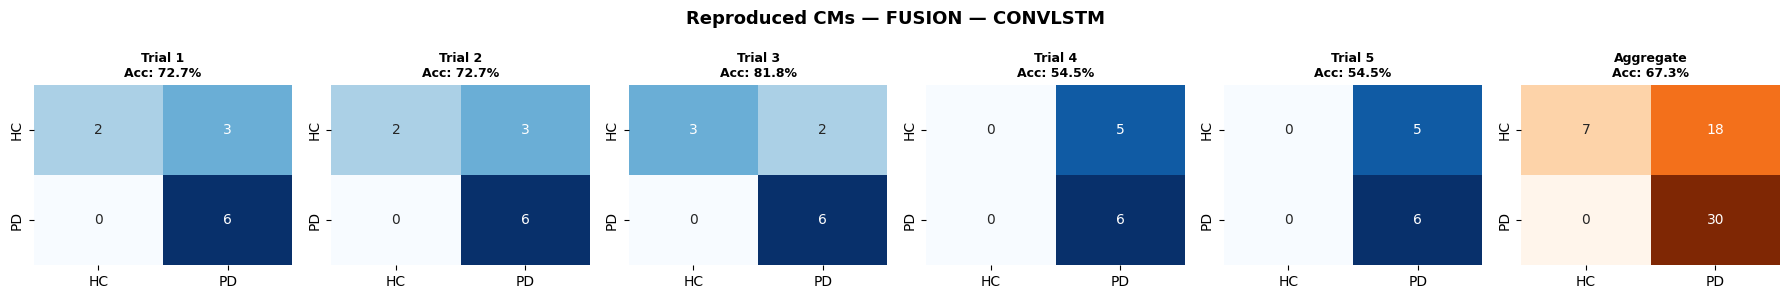


FUSION — Reproducing VIT

  --- Trial 1 (type1) ---  cache-match 100.0% [OK]
  N_test=11 | TrAcc=60.5% | TeAcc=63.6%  Prec=60.0%  Rec=100.0%  F1=75.0%
  CM:           HC    PD
        HC      1     4
        PD      0     6

  --- Trial 2 (type1) ---  cache-match 100.0% [OK]
  N_test=11 | TrAcc=100.0% | TeAcc=100.0%  Prec=100.0%  Rec=100.0%  F1=100.0%
  CM:           HC    PD
        HC      5     0
        PD      0     6

  --- Trial 3 (type1) ---  cache-match 100.0% [OK]
  N_test=11 | TrAcc=100.0% | TeAcc=81.8%  Prec=83.3%  Rec=83.3%  F1=83.3%
  CM:           HC    PD
        HC      4     1
        PD      1     5

  --- Trial 4 (type1) ---  cache-match 100.0% [OK]
  N_test=11 | TrAcc=100.0% | TeAcc=100.0%  Prec=100.0%  Rec=100.0%  F1=100.0%
  CM:           HC    PD
        HC      5     0
        PD      0     6

  --- Trial 5 (type1) ---  cache-match 100.0% [OK]
  N_test=11 | TrAcc=100.0% | TeAcc=72.7%  Prec=80.0%  Rec=66.7%  F1=72.7%
  CM:           HC    PD
        HC      4  

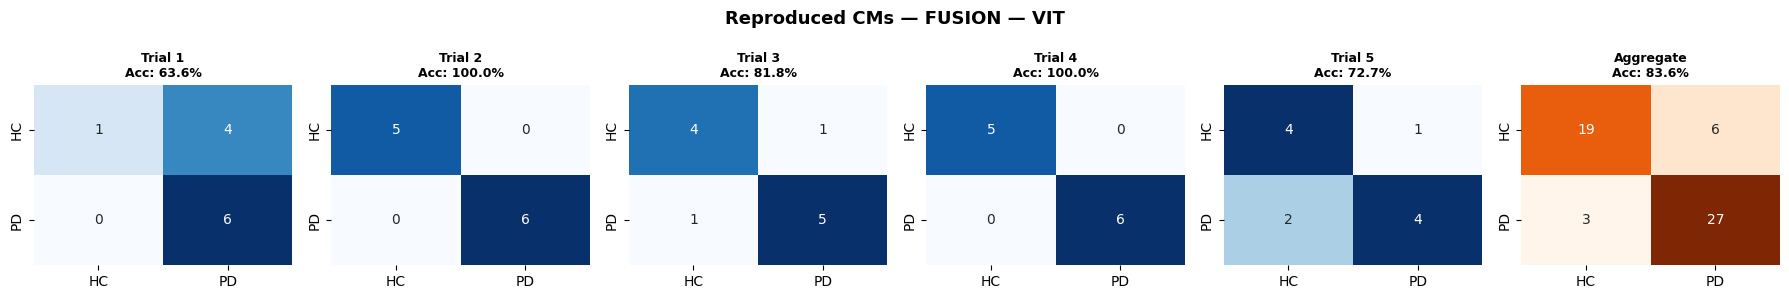


FUSION — Reproducing FLIPFLOP

  --- Trial 1 (type1) ---  cache-match 100.0% [OK]
  N_test=11 | TrAcc=100.0% | TeAcc=90.9%  Prec=100.0%  Rec=83.3%  F1=90.9%
  CM:           HC    PD
        HC      5     0
        PD      1     5

  --- Trial 2 (type1) ---  cache-match 100.0% [OK]
  N_test=11 | TrAcc=89.5% | TeAcc=90.9%  Prec=100.0%  Rec=83.3%  F1=90.9%
  CM:           HC    PD
        HC      5     0
        PD      1     5

  --- Trial 3 (type1) ---  cache-match 100.0% [OK]
  N_test=11 | TrAcc=92.1% | TeAcc=81.8%  Prec=75.0%  Rec=100.0%  F1=85.7%
  CM:           HC    PD
        HC      3     2
        PD      0     6

  --- Trial 4 (type1) ---  cache-match 100.0% [OK]
  N_test=11 | TrAcc=55.3% | TeAcc=54.5%  Prec=54.5%  Rec=100.0%  F1=70.6%
  CM:           HC    PD
        HC      0     5
        PD      0     6

  --- Trial 5 (type1) ---  cache-match 100.0% [OK]
  N_test=11 | TrAcc=55.3% | TeAcc=54.5%  Prec=54.5%  Rec=100.0%  F1=70.6%
  CM:           HC    PD
        HC      0    

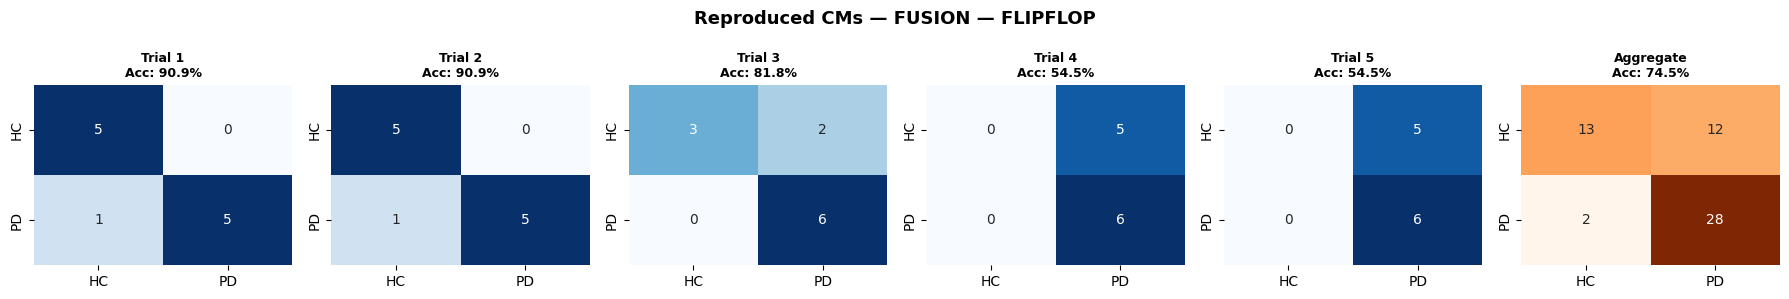



GRAND COMPARISON (Reproduced) — FUSION Multimodal
  Branch      Trials   Mean Acc    Std Acc    Mean F1     Std F1
  ------------------------------------------------------------
  convlstm         5      67.3%      10.9%      77.4%       5.9%
  vit              5      83.6%      14.5%      86.2%      11.8%
  flipflop         5      74.5%      16.7%      81.7%       9.3%


In [ ]:
# ============================================================
# Reproduce Multimodal PD — FUSION (concat → MLP) — STANDALONE
# Reads multimodal_v2_models/{branch_type}/trial_{k}/ and reproduces
# all 5 trials' metrics + confusion matrices from saved checkpoints.
#
# Standalone — no dependency on the training script.
#
# Saved per trial (from run_trial in multimodal_pd_v2.py):
#   best.pth, last.pth
#   trial_data.pkl with keys:
#     branch_type, combo_method, train_combos, test_combos,
#     mod_order, mod_channels, subject_splits (type3 only),
#     X_train, y_train, X_test, y_test  (already normalized),
#     best_preds, best_labels, best_test_acc, best_train_acc
# ============================================================

import pickle
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURATION — edit these
# ============================================================
MODEL_FOLDER  = Path("/content/drive/MyDrive/multimodal_v3_models")        # ← your saved drive path
BRANCH_TYPES  = ['convlstm', 'vit','flipflop']
N_TRIALS      = 5
BATCH_SIZE    = 4
N_FREQ        = 32
N_TIME        = 32
DEVICE        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Device       : {DEVICE}")
print(f"Model folder : {MODEL_FOLDER.resolve()}")


# ============================================================
# DATASET
# ============================================================
class MultimodalDataset(Dataset):
    def __init__(self, X_dict, y, modality_order):
        self.modality_order = modality_order
        self.X = {mod: torch.FloatTensor(X_dict[mod]) for mod in modality_order}
        self.y = torch.LongTensor(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        sample = {mod: self.X[mod][idx] for mod in self.modality_order}
        return sample, self.y[idx]


# ============================================================
# BRANCH MODELS — must match training architecture exactly
# ============================================================
class ConvLSTMCell(nn.Module):
    def __init__(self, in_ch, hid_ch, ks=3):
        super().__init__()
        self.hid_ch = hid_ch
        self.conv = nn.Conv2d(in_ch + hid_ch, 4 * hid_ch, ks, padding=ks // 2)

    def forward(self, x, h, c):
        gates = self.conv(torch.cat([x, h], dim=1))
        i, f, o, g = gates.chunk(4, dim=1)
        c_new = torch.sigmoid(f) * c + torch.sigmoid(i) * torch.tanh(g)
        h_new = torch.sigmoid(o) * torch.tanh(c_new)
        return h_new, c_new


class ConvLSTM2D(nn.Module):
    def __init__(self, in_ch, hid_ch, ks=3, return_seq=False):
        super().__init__()
        self.hid_ch = hid_ch
        self.return_seq = return_seq
        self.cell = ConvLSTMCell(in_ch, hid_ch, ks)

    def forward(self, x):
        B, T, C, H, W = x.size()
        h = torch.zeros(B, self.hid_ch, H, W, device=x.device)
        c = torch.zeros(B, self.hid_ch, H, W, device=x.device)
        outs = []
        for t in range(T):
            h, c = self.cell(x[:, t], h, c)
            outs.append(h)
        return torch.stack(outs, 1) if self.return_seq else h


class ModalityBranchConvLSTM(nn.Module):
    def __init__(self, in_channels=1, feat_dim=64):
        super().__init__()
        self.clstm1 = ConvLSTM2D(in_channels, 32, ks=3, return_seq=True)
        self.drop1  = nn.Dropout(0.2)
        self.clstm2 = ConvLSTM2D(32, 16, ks=3, return_seq=False)
        self.drop2  = nn.Dropout(0.2)
        self.fc     = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * N_FREQ, feat_dim),
            nn.ReLU()
        )

    def forward(self, x):
        x = x.permute(0, 3, 1, 2).unsqueeze(-1)
        x = self.drop1(self.clstm1(x))
        x = self.drop2(self.clstm2(x))
        return self.fc(x)


class FlipFlopCell2D(nn.Module):
    def __init__(self, in_ch, hid_ch, ks=3):
        super().__init__()
        p = ks // 2
        self.conv_xj = nn.Conv2d(in_ch, hid_ch, ks, padding=p)
        self.conv_hj = nn.Conv2d(hid_ch, hid_ch, ks, padding=p)
        self.conv_xk = nn.Conv2d(in_ch, hid_ch, ks, padding=p)
        self.conv_hk = nn.Conv2d(hid_ch, hid_ch, ks, padding=p)

    def forward(self, x, h_prev):
        j = torch.sigmoid(self.conv_xj(x) + self.conv_hj(h_prev))
        k = torch.sigmoid(self.conv_xk(x) + self.conv_hk(h_prev))
        return (1 - h_prev) * j + (1 - k) * h_prev


class FlipFlop2D(nn.Module):
    def __init__(self, in_ch, hid_ch, ks=3, return_seq=False):
        super().__init__()
        self.hid_ch = hid_ch
        self.return_seq = return_seq
        self.cell = FlipFlopCell2D(in_ch, hid_ch, ks)

    def forward(self, x):
        B, T, C, H, W = x.size()
        h = torch.zeros(B, self.hid_ch, H, W, device=x.device)
        outs = []
        for t in range(T):
            h = self.cell(x[:, t], h)
            outs.append(h)
        return torch.stack(outs, 1) if self.return_seq else h


class ModalityBranchFlipFlop(nn.Module):
    def __init__(self, in_channels=1, feat_dim=64):
        super().__init__()
        self.ff1   = FlipFlop2D(in_channels, 64, ks=3, return_seq=True)
        self.drop1 = nn.Dropout(0.15)
        self.ff2   = FlipFlop2D(64, 32, ks=3, return_seq=False)
        self.drop2 = nn.Dropout(0.15)
        self.fc    = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * N_FREQ, feat_dim),
            nn.ReLU()
        )

    def forward(self, x):
        x = x.permute(0, 3, 1, 2).unsqueeze(-1)
        x = self.drop1(self.ff1(x))
        x = self.drop2(self.ff2(x))
        return self.fc(x)


class TransformerBlock(nn.Module):
    def __init__(self, dim, heads, mlp_dim, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = nn.MultiheadAttention(dim, heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp   = nn.Sequential(
            nn.Linear(dim, mlp_dim), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, dim), nn.Dropout(dropout)
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))
        return x


class ModalityBranchViT(nn.Module):
    def __init__(self, in_channels=1, feat_dim=64,
                 img_size=(N_FREQ, N_TIME),
                 patch_size=4, dim=64, heads=4, layers=3, dropout=0.1):
        super().__init__()
        nf, nt = img_size
        n_patches = (nf // patch_size) * (nt // patch_size)
        self.proj = nn.Conv2d(in_channels, dim, kernel_size=patch_size, stride=patch_size)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches + 1, dim))
        self.dropout   = nn.Dropout(dropout)
        self.blocks    = nn.ModuleList([
            TransformerBlock(dim, heads, dim * 4, dropout) for _ in range(layers)
        ])
        self.norm = nn.LayerNorm(dim)
        self.head = nn.Sequential(nn.Linear(dim, feat_dim), nn.ReLU())
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, x):
        x = self.proj(x).flatten(2).transpose(1, 2)
        cls = self.cls_token.expand(x.size(0), -1, -1)
        x = torch.cat([cls, x], dim=1) + self.pos_embed
        x = self.dropout(x)
        for block in self.blocks:
            x = block(x)
        return self.head(self.norm(x[:, 0]))


BRANCH_CLASSES = {
    'convlstm': ModalityBranchConvLSTM,
    'flipflop': ModalityBranchFlipFlop,
    'vit':      ModalityBranchViT,
}


# ============================================================
# FUSION CLASSIFIER — concat features then MLP
# ============================================================
class MultimodalPDClassifier(nn.Module):
    def __init__(self, modality_names, modality_channels, branch_type='convlstm',
                 branch_feat_dim=64):
        super().__init__()
        self.modality_names = modality_names
        self.branch_type = branch_type
        BranchClass = BRANCH_CLASSES[branch_type]
        self.branches = nn.ModuleDict({
            mod: BranchClass(in_channels=modality_channels[mod],
                             feat_dim=branch_feat_dim)
            for mod in modality_names
        })
        total_feat = branch_feat_dim * len(modality_names)
        self.classifier = nn.Sequential(
            nn.Linear(total_feat, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64),         nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 2)
        )

    def forward(self, x_dict):
        feats = [self.branches[mod](x_dict[mod]) for mod in self.modality_names]
        return self.classifier(torch.cat(feats, dim=1))


# ============================================================
# CORE REPRODUCTION
# ============================================================
def reproduce_trial(branch_type, trial_num, verify_against_cache=True):
    """
    Reproduce one fusion trial.
    Returns dict with preds, labels, metrics. Also reports cache match.
    """
    trial_dir = MODEL_FOLDER / branch_type / f"trial_{trial_num}"
    pkl_path  = trial_dir / "trial_data.pkl"
    ckpt_path = trial_dir / "best.pth"

    if not pkl_path.exists():
        raise FileNotFoundError(f"Missing {pkl_path}")
    if not ckpt_path.exists():
        raise FileNotFoundError(f"Missing {ckpt_path}")

    with open(pkl_path, 'rb') as f:
        td = pickle.load(f)

    # Use the branch_type stored in the pickle — should match folder, but trust pkl
    saved_branch = td.get('branch_type', branch_type)
    mod_order    = td['mod_order']
    mod_channels = td['mod_channels']
    X_test       = td['X_test']
    y_test       = td['y_test']
    X_train      = td['X_train']
    y_train      = td['y_train']
    cached_preds = td['best_preds']

    # Build model + load weights
    model = MultimodalPDClassifier(mod_order, mod_channels,
                                   branch_type=saved_branch).to(DEVICE)
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    model.eval()

    def run_inference(X_dict, y):
        loader = DataLoader(MultimodalDataset(X_dict, y, mod_order),
                            batch_size=BATCH_SIZE, shuffle=False)
        all_preds, all_labels = [], []
        with torch.no_grad():
            for batch_x, batch_y in loader:
                batch_x = {m: batch_x[m].to(DEVICE) for m in mod_order}
                out = model(batch_x)
                all_preds.extend(out.argmax(1).cpu().numpy())
                all_labels.extend(batch_y.numpy())
        return np.array(all_preds), np.array(all_labels)

    test_preds,  test_labels  = run_inference(X_test,  y_test)
    train_preds, train_labels = run_inference(X_train, y_train)

    # Cache check
    cache_match = None
    if verify_against_cache and cached_preds is not None:
        if len(cached_preds) == len(test_preds):
            cache_match = (np.array(cached_preds) == test_preds).mean() * 100

    test_acc  = accuracy_score(test_labels, test_preds)
    train_acc = accuracy_score(train_labels, train_preds)
    prec      = precision_score(test_labels, test_preds, zero_division=0)
    rec       = recall_score(test_labels, test_preds, zero_division=0)
    f1        = f1_score(test_labels, test_preds, zero_division=0)
    cm        = confusion_matrix(test_labels, test_preds)

    return {
        'test_preds':  test_preds,
        'test_labels': test_labels,
        'train_preds': train_preds,
        'train_labels': train_labels,
        'metrics': {
            'acc': test_acc, 'prec': prec, 'rec': rec, 'f1': f1,
            'cm': cm, 'train_acc': train_acc,
        },
        'cache_match':   cache_match,
        'mod_order':     mod_order,
        'mod_channels':  mod_channels,
        'combo_method':  td.get('combo_method', 'unknown'),
        'train_combos':  td.get('train_combos', []),
        'test_combos':   td.get('test_combos', []),
    }


def reproduce_all_trials(branch_type, verify_against_cache=True):
    """Reproduce all 5 trials for a given branch type."""
    print(f"\n{'='*65}")
    print(f"FUSION — Reproducing {branch_type.upper()}")
    print(f"{'='*65}")

    branch_dir = MODEL_FOLDER / branch_type
    if not branch_dir.exists():
        raise FileNotFoundError(f"No branch dir: {branch_dir}")

    trial_results = []

    for t in range(1, N_TRIALS + 1):
        try:
            r = reproduce_trial(branch_type, t, verify_against_cache)
        except FileNotFoundError as e:
            print(f"\n  [SKIP] Trial {t}: {e}")
            continue

        m = r['metrics']
        cm = m['cm']
        tag = ""
        if r['cache_match'] is not None:
            flag = "OK" if r['cache_match'] == 100.0 else "WARN"
            tag = f"  cache-match {r['cache_match']:.1f}% [{flag}]"

        print(f"\n  --- Trial {t} ({r['combo_method']}) ---{tag}")
        print(f"  N_test={len(r['test_labels'])} | "
              f"TrAcc={m['train_acc']*100:.1f}% | "
              f"TeAcc={m['acc']*100:.1f}%  Prec={m['prec']*100:.1f}%  "
              f"Rec={m['rec']*100:.1f}%  F1={m['f1']*100:.1f}%")
        print(f"  CM:           HC    PD")
        print(f"        HC   {cm[0,0]:4d}  {cm[0,1]:4d}")
        print(f"        PD   {cm[1,0]:4d}  {cm[1,1]:4d}")

        trial_results.append({'trial': t, **r})

    return trial_results


# ============================================================
# SUMMARY + PLOTTING
# ============================================================
def print_summary(trial_results, branch_type):
    print(f"\n{'='*60}")
    print(f"Reproduction Summary — FUSION — {branch_type.upper()}")
    print(f"{'='*60}")
    if not trial_results:
        print("  (no trials reproduced)")
        return

    print(f"  {'Trial':<7} {'TrAcc':>8} {'TeAcc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8}")
    print(f"  {'-'*52}")
    for r in trial_results:
        m = r['metrics']
        print(f"  {r['trial']:<7} {m['train_acc']*100:>7.1f}% {m['acc']*100:>7.1f}% "
              f"{m['prec']*100:>7.1f}% {m['rec']*100:>7.1f}% {m['f1']*100:>7.1f}%")
    print(f"  {'-'*52}")
    accs = [r['metrics']['acc']  for r in trial_results]
    pres = [r['metrics']['prec'] for r in trial_results]
    recs = [r['metrics']['rec']  for r in trial_results]
    f1s  = [r['metrics']['f1']   for r in trial_results]
    print(f"  {'Mean':<7} {'':>8} {np.mean(accs)*100:>7.1f}% "
          f"{np.mean(pres)*100:>7.1f}% {np.mean(recs)*100:>7.1f}% "
          f"{np.mean(f1s)*100:>7.1f}%")
    print(f"  {'Std':<7} {'':>8} {np.std(accs)*100:>7.1f}%  "
          f"{np.std(pres)*100:>7.1f}%  {np.std(recs)*100:>7.1f}%  "
          f"{np.std(f1s)*100:>7.1f}%")


def plot_confusion_matrices(trial_results, branch_type, save_dir=None):
    n = len(trial_results)
    if n == 0:
        return
    n_cols = n + 1
    fig, axes = plt.subplots(1, n_cols, figsize=(3.0 * n_cols, 3.0))
    if n_cols == 1:
        axes = [axes]
    fig.suptitle(f'Reproduced CMs — FUSION — {branch_type.upper()}',
                 fontsize=13, fontweight='bold')

    all_preds, all_labels = [], []
    for i, r in enumerate(trial_results):
        m  = r['metrics']
        cm = m['cm']
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                    cbar=False, xticklabels=['HC', 'PD'], yticklabels=['HC', 'PD'])
        axes[i].set_title(f"Trial {r['trial']}\nAcc: {m['acc']*100:.1f}%",
                          fontsize=9, fontweight='bold')
        all_preds.extend(r['test_preds'])
        all_labels.extend(r['test_labels'])

    cm_all  = confusion_matrix(all_labels, all_preds)
    avg_acc = np.mean([r['metrics']['acc'] for r in trial_results])
    sns.heatmap(cm_all, annot=True, fmt='d', cmap='Oranges', ax=axes[-1],
                cbar=False, xticklabels=['HC', 'PD'], yticklabels=['HC', 'PD'])
    axes[-1].set_title(f"Aggregate\nAcc: {avg_acc*100:.1f}%",
                       fontsize=9, fontweight='bold')

    plt.tight_layout()
    if save_dir is not None:
        out = Path(save_dir) / f"fusion_{branch_type}_reproduced_cm.png"
        plt.savefig(out, dpi=150, bbox_inches='tight')
        print(f"  Saved: {out}")
    plt.show()


# ============================================================
# MAIN
# ============================================================
if __name__ == '__main__':
    grand = {}
    for bt in BRANCH_TYPES:
        try:
            results = reproduce_all_trials(bt, verify_against_cache=True)
            if results:
                print_summary(results, bt)
                plot_confusion_matrices(results, bt, save_dir=MODEL_FOLDER)
                grand[bt] = results
        except FileNotFoundError as e:
            print(f"\n[SKIP] {bt}: {e}")

    # Cross-branch table
    print(f"\n\n{'='*75}")
    print(f"GRAND COMPARISON (Reproduced) — FUSION Multimodal")
    print(f"{'='*75}")
    print(f"  {'Branch':<10} {'Trials':>7} {'Mean Acc':>10} {'Std Acc':>10} "
          f"{'Mean F1':>10} {'Std F1':>10}")
    print(f"  {'-'*60}")
    for bt in BRANCH_TYPES:
        if bt not in grand:
            continue
        results = grand[bt]
        accs = [r['metrics']['acc'] for r in results]
        f1s  = [r['metrics']['f1']  for r in results]
        print(f"  {bt:<10} {len(accs):>7} "
              f"{np.mean(accs)*100:>9.1f}% {np.std(accs)*100:>9.1f}% "
              f"{np.mean(f1s)*100:>9.1f}% {np.std(f1s)*100:>9.1f}%")

Device       : cuda
Model folder : /content/drive/MyDrive/multimodal_v3_ensemble

ENSEMBLE — Reproducing CONVLSTM

  --- Trial 1 ---  cache-match 100.0% [OK]
  N_test=11 | TrAcc=97.4% | TeAcc=81.8%  Prec=75.0%  Rec=100.0%  F1=85.7%
  CM:           HC    PD
        HC      3     2
        PD      0     6

  --- Trial 2 ---  cache-match 100.0% [OK]
  N_test=11 | TrAcc=100.0% | TeAcc=81.8%  Prec=83.3%  Rec=83.3%  F1=83.3%
  CM:           HC    PD
        HC      4     1
        PD      1     5

  --- Trial 3 ---  cache-match 100.0% [OK]
  N_test=11 | TrAcc=94.7% | TeAcc=72.7%  Prec=66.7%  Rec=100.0%  F1=80.0%
  CM:           HC    PD
        HC      2     3
        PD      0     6

  --- Trial 4 ---  cache-match 100.0% [OK]
  N_test=11 | TrAcc=100.0% | TeAcc=63.6%  Prec=75.0%  Rec=50.0%  F1=60.0%
  CM:           HC    PD
        HC      4     1
        PD      3     3

  --- Trial 5 ---  cache-match 100.0% [OK]
  N_test=11 | TrAcc=100.0% | TeAcc=81.8%  Prec=75.0%  Rec=100.0%  F1=85.7%
  C

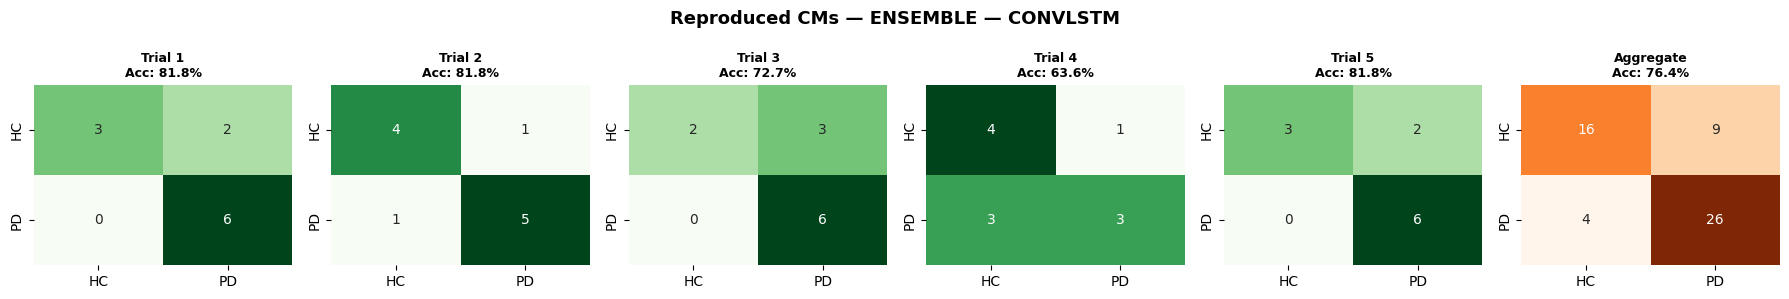


ENSEMBLE — Reproducing FLIPFLOP

  --- Trial 1 ---  cache-match 100.0% [OK]
  N_test=11 | TrAcc=76.3% | TeAcc=81.8%  Prec=83.3%  Rec=83.3%  F1=83.3%
  CM:           HC    PD
        HC      4     1
        PD      1     5

  --- Trial 2 ---  cache-match 100.0% [OK]
  N_test=11 | TrAcc=73.7% | TeAcc=90.9%  Prec=100.0%  Rec=83.3%  F1=90.9%
  CM:           HC    PD
        HC      5     0
        PD      1     5

  --- Trial 3 ---  cache-match 100.0% [OK]
  N_test=11 | TrAcc=55.3% | TeAcc=54.5%  Prec=54.5%  Rec=100.0%  F1=70.6%
  CM:           HC    PD
        HC      0     5
        PD      0     6

  --- Trial 4 ---  cache-match 100.0% [OK]
  N_test=11 | TrAcc=76.3% | TeAcc=90.9%  Prec=100.0%  Rec=83.3%  F1=90.9%
  CM:           HC    PD
        HC      5     0
        PD      1     5

  --- Trial 5 ---  cache-match 100.0% [OK]
  N_test=11 | TrAcc=97.4% | TeAcc=90.9%  Prec=85.7%  Rec=100.0%  F1=92.3%
  CM:           HC    PD
        HC      4     1
        PD      0     6

Reproduction

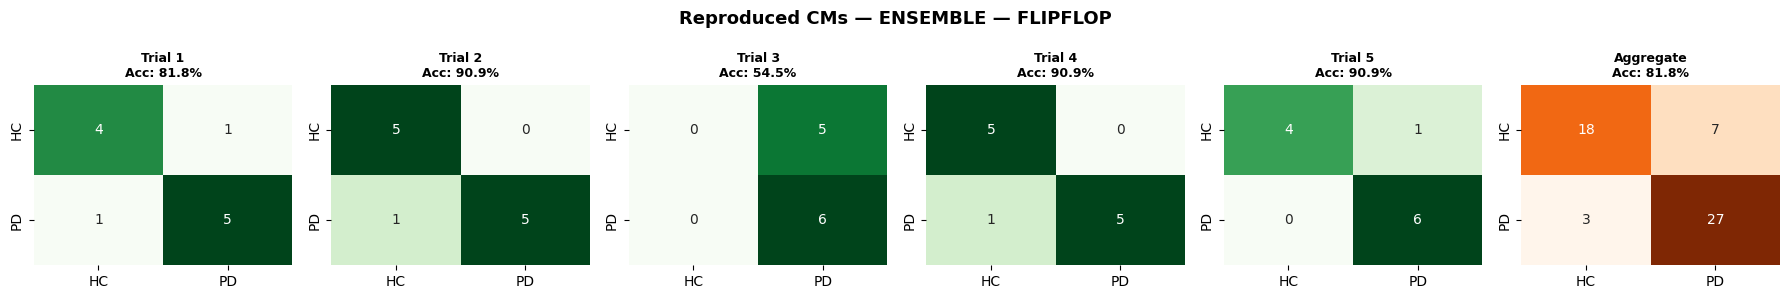


ENSEMBLE — Reproducing VIT

  --- Trial 1 ---  cache-match 100.0% [OK]
  N_test=11 | TrAcc=100.0% | TeAcc=90.9%  Prec=100.0%  Rec=83.3%  F1=90.9%
  CM:           HC    PD
        HC      5     0
        PD      1     5

  --- Trial 2 ---  cache-match 100.0% [OK]
  N_test=11 | TrAcc=81.6% | TeAcc=90.9%  Prec=85.7%  Rec=100.0%  F1=92.3%
  CM:           HC    PD
        HC      4     1
        PD      0     6

  --- Trial 3 ---  cache-match 100.0% [OK]
  N_test=11 | TrAcc=97.4% | TeAcc=81.8%  Prec=75.0%  Rec=100.0%  F1=85.7%
  CM:           HC    PD
        HC      3     2
        PD      0     6

  --- Trial 4 ---  cache-match 100.0% [OK]
  N_test=11 | TrAcc=94.7% | TeAcc=100.0%  Prec=100.0%  Rec=100.0%  F1=100.0%
  CM:           HC    PD
        HC      5     0
        PD      0     6

  --- Trial 5 ---  cache-match 100.0% [OK]
  N_test=11 | TrAcc=97.4% | TeAcc=90.9%  Prec=85.7%  Rec=100.0%  F1=92.3%
  CM:           HC    PD
        HC      4     1
        PD      0     6

Reproduction

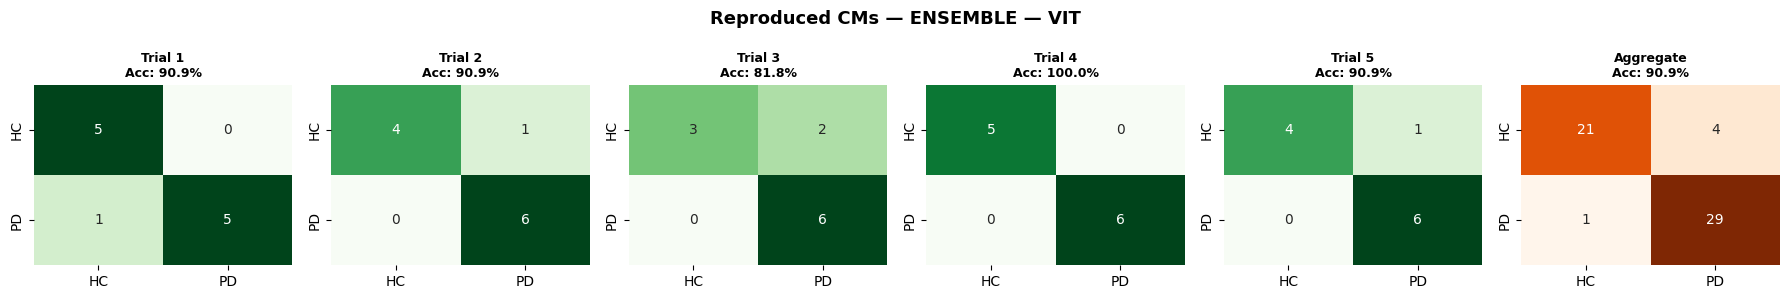



GRAND COMPARISON (Reproduced) — ENSEMBLE Multimodal
  Branch      Trials   Mean Acc    Std Acc    Mean F1     Std F1
  ------------------------------------------------------------
  convlstm         5      76.4%       7.3%      79.0%       9.7%
  flipflop         5      81.8%      14.1%      85.6%       8.1%
  vit              5      90.9%       5.7%      92.2%       4.6%


In [ ]:
# ============================================================
# Reproduce Multimodal PD — ENSEMBLE (avg softmax) — STANDALONE
# Reads multimodal_v2_ensemble/{branch_type}/trial_{k}/ and reproduces
# all 5 trials' metrics + confusion matrices from saved checkpoints.
#
# Standalone — no dependency on the training script.
#
# Saved per trial (from run_trial_ensemble):
#   best.pth, last.pth
#   trial_data.pkl with keys:
#     branch_type, combos, mod_order, mod_channels,
#     train_idx, test_idx,
#     X_train, y_train, X_test, y_test  (already normalized),
#     best_preds, best_labels, best_test_acc, best_train_acc,
#     train_losses, te_losses, train_accs, te_accs
# ============================================================

import pickle
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# CONFIGURATION — edit these
# ============================================================
MODEL_FOLDER  = Path("/content/drive/MyDrive/multimodal_v3_ensemble")      # ← your saved drive path
BRANCH_TYPES  = ['convlstm', 'flipflop', 'vit']
N_TRIALS      = 5
BATCH_SIZE    = 4
N_FREQ        = 32
N_TIME        = 32
DEVICE        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Device       : {DEVICE}")
print(f"Model folder : {MODEL_FOLDER.resolve()}")


# ============================================================
# DATASET (same as fusion)
# ============================================================
class MultimodalDataset(Dataset):
    def __init__(self, X_dict, y, modality_order):
        self.modality_order = modality_order
        self.X = {mod: torch.FloatTensor(X_dict[mod]) for mod in modality_order}
        self.y = torch.LongTensor(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        sample = {mod: self.X[mod][idx] for mod in self.modality_order}
        return sample, self.y[idx]


# ============================================================
# BRANCH MODELS — must match training architecture exactly
# (identical to fusion script — same branches, different head)
# ============================================================
class ConvLSTMCell(nn.Module):
    def __init__(self, in_ch, hid_ch, ks=3):
        super().__init__()
        self.hid_ch = hid_ch
        self.conv = nn.Conv2d(in_ch + hid_ch, 4 * hid_ch, ks, padding=ks // 2)

    def forward(self, x, h, c):
        gates = self.conv(torch.cat([x, h], dim=1))
        i, f, o, g = gates.chunk(4, dim=1)
        c_new = torch.sigmoid(f) * c + torch.sigmoid(i) * torch.tanh(g)
        h_new = torch.sigmoid(o) * torch.tanh(c_new)
        return h_new, c_new


class ConvLSTM2D(nn.Module):
    def __init__(self, in_ch, hid_ch, ks=3, return_seq=False):
        super().__init__()
        self.hid_ch = hid_ch
        self.return_seq = return_seq
        self.cell = ConvLSTMCell(in_ch, hid_ch, ks)

    def forward(self, x):
        B, T, C, H, W = x.size()
        h = torch.zeros(B, self.hid_ch, H, W, device=x.device)
        c = torch.zeros(B, self.hid_ch, H, W, device=x.device)
        outs = []
        for t in range(T):
            h, c = self.cell(x[:, t], h, c)
            outs.append(h)
        return torch.stack(outs, 1) if self.return_seq else h


class ModalityBranchConvLSTM(nn.Module):
    def __init__(self, in_channels=1, feat_dim=64):
        super().__init__()
        self.clstm1 = ConvLSTM2D(in_channels, 32, ks=3, return_seq=True)
        self.drop1  = nn.Dropout(0.2)
        self.clstm2 = ConvLSTM2D(32, 16, ks=3, return_seq=False)
        self.drop2  = nn.Dropout(0.2)
        self.fc     = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * N_FREQ, feat_dim),
            nn.ReLU()
        )

    def forward(self, x):
        x = x.permute(0, 3, 1, 2).unsqueeze(-1)
        x = self.drop1(self.clstm1(x))
        x = self.drop2(self.clstm2(x))
        return self.fc(x)


class FlipFlopCell2D(nn.Module):
    def __init__(self, in_ch, hid_ch, ks=3):
        super().__init__()
        p = ks // 2
        self.conv_xj = nn.Conv2d(in_ch, hid_ch, ks, padding=p)
        self.conv_hj = nn.Conv2d(hid_ch, hid_ch, ks, padding=p)
        self.conv_xk = nn.Conv2d(in_ch, hid_ch, ks, padding=p)
        self.conv_hk = nn.Conv2d(hid_ch, hid_ch, ks, padding=p)

    def forward(self, x, h_prev):
        j = torch.sigmoid(self.conv_xj(x) + self.conv_hj(h_prev))
        k = torch.sigmoid(self.conv_xk(x) + self.conv_hk(h_prev))
        return (1 - h_prev) * j + (1 - k) * h_prev


class FlipFlop2D(nn.Module):
    def __init__(self, in_ch, hid_ch, ks=3, return_seq=False):
        super().__init__()
        self.hid_ch = hid_ch
        self.return_seq = return_seq
        self.cell = FlipFlopCell2D(in_ch, hid_ch, ks)

    def forward(self, x):
        B, T, C, H, W = x.size()
        h = torch.zeros(B, self.hid_ch, H, W, device=x.device)
        outs = []
        for t in range(T):
            h = self.cell(x[:, t], h)
            outs.append(h)
        return torch.stack(outs, 1) if self.return_seq else h


class ModalityBranchFlipFlop(nn.Module):
    def __init__(self, in_channels=1, feat_dim=64):
        super().__init__()
        self.ff1   = FlipFlop2D(in_channels, 64, ks=3, return_seq=True)
        self.drop1 = nn.Dropout(0.15)
        self.ff2   = FlipFlop2D(64, 32, ks=3, return_seq=False)
        self.drop2 = nn.Dropout(0.15)
        self.fc    = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * N_FREQ, feat_dim),
            nn.ReLU()
        )

    def forward(self, x):
        x = x.permute(0, 3, 1, 2).unsqueeze(-1)
        x = self.drop1(self.ff1(x))
        x = self.drop2(self.ff2(x))
        return self.fc(x)


class TransformerBlock(nn.Module):
    def __init__(self, dim, heads, mlp_dim, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = nn.MultiheadAttention(dim, heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp   = nn.Sequential(
            nn.Linear(dim, mlp_dim), nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, dim), nn.Dropout(dropout)
        )

    def forward(self, x):
        x = x + self.attn(self.norm1(x), self.norm1(x), self.norm1(x))[0]
        x = x + self.mlp(self.norm2(x))
        return x


class ModalityBranchViT(nn.Module):
    def __init__(self, in_channels=1, feat_dim=64,
                 img_size=(N_FREQ, N_TIME),
                 patch_size=4, dim=64, heads=4, layers=3, dropout=0.1):
        super().__init__()
        nf, nt = img_size
        n_patches = (nf // patch_size) * (nt // patch_size)
        self.proj = nn.Conv2d(in_channels, dim, kernel_size=patch_size, stride=patch_size)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, dim))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patches + 1, dim))
        self.dropout   = nn.Dropout(dropout)
        self.blocks    = nn.ModuleList([
            TransformerBlock(dim, heads, dim * 4, dropout) for _ in range(layers)
        ])
        self.norm = nn.LayerNorm(dim)
        self.head = nn.Sequential(nn.Linear(dim, feat_dim), nn.ReLU())
        nn.init.trunc_normal_(self.pos_embed, std=0.02)
        nn.init.trunc_normal_(self.cls_token, std=0.02)

    def forward(self, x):
        x = self.proj(x).flatten(2).transpose(1, 2)
        cls = self.cls_token.expand(x.size(0), -1, -1)
        x = torch.cat([cls, x], dim=1) + self.pos_embed
        x = self.dropout(x)
        for block in self.blocks:
            x = block(x)
        return self.head(self.norm(x[:, 0]))


BRANCH_CLASSES = {
    'convlstm': ModalityBranchConvLSTM,
    'flipflop': ModalityBranchFlipFlop,
    'vit':      ModalityBranchViT,
}


# ============================================================
# ENSEMBLE CLASSIFIER — per-modality head, mean of softmax
# ============================================================
class EnsemblePDClassifier(nn.Module):
    def __init__(self, modality_names, modality_channels,
                 branch_type='convlstm', branch_feat_dim=64):
        super().__init__()
        self.modality_names = modality_names
        BranchClass = BRANCH_CLASSES[branch_type]
        self.branches = nn.ModuleDict({
            mod: BranchClass(in_channels=modality_channels[mod],
                             feat_dim=branch_feat_dim)
            for mod in modality_names
        })
        self.heads = nn.ModuleDict({
            mod: nn.Linear(branch_feat_dim, 2)
            for mod in modality_names
        })

    def forward(self, x_dict):
        """Returns averaged softmax probabilities (B, 2)."""
        probs_list = []
        for mod in self.modality_names:
            feat  = self.branches[mod](x_dict[mod])
            logit = self.heads[mod](feat)
            probs_list.append(F.softmax(logit, dim=-1))
        return torch.stack(probs_list, dim=0).mean(dim=0)

    def per_modality_probs(self, x_dict):
        """Returns dict {mod: (B, 2) softmax probs}."""
        out = {}
        for mod in self.modality_names:
            feat  = self.branches[mod](x_dict[mod])
            logit = self.heads[mod](feat)
            out[mod] = F.softmax(logit, dim=-1)
        return out


# ============================================================
# CORE REPRODUCTION
# ============================================================
def reproduce_trial(branch_type, trial_num, verify_against_cache=True,
                    capture_per_modality=False):
    """
    Reproduce one ensemble trial.
    If capture_per_modality=True, also returns per-modality predictions
    (so you can see which modality drove correct/wrong calls).
    """
    trial_dir = MODEL_FOLDER / branch_type / f"trial_{trial_num}"
    pkl_path  = trial_dir / "trial_data.pkl"
    ckpt_path = trial_dir / "best.pth"

    if not pkl_path.exists():
        raise FileNotFoundError(f"Missing {pkl_path}")
    if not ckpt_path.exists():
        raise FileNotFoundError(f"Missing {ckpt_path}")

    with open(pkl_path, 'rb') as f:
        td = pickle.load(f)

    saved_branch = td.get('branch_type', branch_type)
    mod_order    = td['mod_order']
    mod_channels = td['mod_channels']
    X_test       = td['X_test']
    y_test       = td['y_test']
    X_train      = td['X_train']
    y_train      = td['y_train']
    cached_preds = td.get('best_preds')

    model = EnsemblePDClassifier(mod_order, mod_channels,
                                 branch_type=saved_branch).to(DEVICE)
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    model.eval()

    def run_inference(X_dict, y, capture_pm=False):
        loader = DataLoader(MultimodalDataset(X_dict, y, mod_order),
                            batch_size=BATCH_SIZE, shuffle=False)
        all_preds, all_labels = [], []
        per_mod_preds = {mod: [] for mod in mod_order} if capture_pm else None
        with torch.no_grad():
            for batch_x, batch_y in loader:
                batch_x = {m: batch_x[m].to(DEVICE) for m in mod_order}
                avg_probs = model(batch_x)                  # (B, 2)
                all_preds.extend(avg_probs.argmax(1).cpu().numpy())
                all_labels.extend(batch_y.numpy())
                if capture_pm:
                    pm = model.per_modality_probs(batch_x)
                    for mod in mod_order:
                        per_mod_preds[mod].extend(pm[mod].argmax(1).cpu().numpy())
        result = (np.array(all_preds), np.array(all_labels))
        if capture_pm:
            per_mod_preds = {mod: np.array(v) for mod, v in per_mod_preds.items()}
            result = result + (per_mod_preds,)
        return result

    if capture_per_modality:
        test_preds, test_labels, per_mod_test = run_inference(X_test, y_test, True)
    else:
        test_preds, test_labels = run_inference(X_test, y_test, False)
        per_mod_test = None
    train_preds, train_labels = run_inference(X_train, y_train, False)

    cache_match = None
    if verify_against_cache and cached_preds is not None:
        if len(cached_preds) == len(test_preds):
            cache_match = (np.array(cached_preds) == test_preds).mean() * 100

    test_acc  = accuracy_score(test_labels, test_preds)
    train_acc = accuracy_score(train_labels, train_preds)
    prec      = precision_score(test_labels, test_preds, zero_division=0)
    rec       = recall_score(test_labels, test_preds, zero_division=0)
    f1        = f1_score(test_labels, test_preds, zero_division=0)
    cm        = confusion_matrix(test_labels, test_preds)

    out = {
        'test_preds':    test_preds,
        'test_labels':   test_labels,
        'train_preds':   train_preds,
        'train_labels':  train_labels,
        'metrics': {
            'acc': test_acc, 'prec': prec, 'rec': rec, 'f1': f1,
            'cm': cm, 'train_acc': train_acc,
        },
        'cache_match':   cache_match,
        'mod_order':     mod_order,
        'mod_channels':  mod_channels,
    }
    if per_mod_test is not None:
        out['per_modality_test_preds'] = per_mod_test
    return out


def reproduce_all_trials(branch_type, verify_against_cache=True,
                         capture_per_modality=False):
    print(f"\n{'='*65}")
    print(f"ENSEMBLE — Reproducing {branch_type.upper()}")
    print(f"{'='*65}")

    branch_dir = MODEL_FOLDER / branch_type
    if not branch_dir.exists():
        raise FileNotFoundError(f"No branch dir: {branch_dir}")

    trial_results = []

    for t in range(1, N_TRIALS + 1):
        try:
            r = reproduce_trial(branch_type, t, verify_against_cache,
                                capture_per_modality)
        except FileNotFoundError as e:
            print(f"\n  [SKIP] Trial {t}: {e}")
            continue

        m = r['metrics']
        cm = m['cm']
        tag = ""
        if r['cache_match'] is not None:
            flag = "OK" if r['cache_match'] == 100.0 else "WARN"
            tag = f"  cache-match {r['cache_match']:.1f}% [{flag}]"

        print(f"\n  --- Trial {t} ---{tag}")
        print(f"  N_test={len(r['test_labels'])} | "
              f"TrAcc={m['train_acc']*100:.1f}% | "
              f"TeAcc={m['acc']*100:.1f}%  Prec={m['prec']*100:.1f}%  "
              f"Rec={m['rec']*100:.1f}%  F1={m['f1']*100:.1f}%")
        print(f"  CM:           HC    PD")
        print(f"        HC   {cm[0,0]:4d}  {cm[0,1]:4d}")
        print(f"        PD   {cm[1,0]:4d}  {cm[1,1]:4d}")

        # Optional per-modality breakdown
        if capture_per_modality and 'per_modality_test_preds' in r:
            print(f"  Per-modality test accuracy:")
            for mod, preds in r['per_modality_test_preds'].items():
                acc_m = (preds == r['test_labels']).mean() * 100
                print(f"    {mod:<12s}: {acc_m:.1f}%")

        trial_results.append({'trial': t, **r})

    return trial_results


# ============================================================
# SUMMARY + PLOTTING
# ============================================================
def print_summary(trial_results, branch_type):
    print(f"\n{'='*60}")
    print(f"Reproduction Summary — ENSEMBLE — {branch_type.upper()}")
    print(f"{'='*60}")
    if not trial_results:
        print("  (no trials reproduced)")
        return

    print(f"  {'Trial':<7} {'TrAcc':>8} {'TeAcc':>8} {'Prec':>8} {'Rec':>8} {'F1':>8}")
    print(f"  {'-'*52}")
    for r in trial_results:
        m = r['metrics']
        print(f"  {r['trial']:<7} {m['train_acc']*100:>7.1f}% {m['acc']*100:>7.1f}% "
              f"{m['prec']*100:>7.1f}% {m['rec']*100:>7.1f}% {m['f1']*100:>7.1f}%")
    print(f"  {'-'*52}")
    accs = [r['metrics']['acc']  for r in trial_results]
    pres = [r['metrics']['prec'] for r in trial_results]
    recs = [r['metrics']['rec']  for r in trial_results]
    f1s  = [r['metrics']['f1']   for r in trial_results]
    print(f"  {'Mean':<7} {'':>8} {np.mean(accs)*100:>7.1f}% "
          f"{np.mean(pres)*100:>7.1f}% {np.mean(recs)*100:>7.1f}% "
          f"{np.mean(f1s)*100:>7.1f}%")
    print(f"  {'Std':<7} {'':>8} {np.std(accs)*100:>7.1f}%  "
          f"{np.std(pres)*100:>7.1f}%  {np.std(recs)*100:>7.1f}%  "
          f"{np.std(f1s)*100:>7.1f}%")


def plot_confusion_matrices(trial_results, branch_type, save_dir=None):
    n = len(trial_results)
    if n == 0:
        return
    n_cols = n + 1
    fig, axes = plt.subplots(1, n_cols, figsize=(3.0 * n_cols, 3.0))
    if n_cols == 1:
        axes = [axes]
    fig.suptitle(f'Reproduced CMs — ENSEMBLE — {branch_type.upper()}',
                 fontsize=13, fontweight='bold')

    all_preds, all_labels = [], []
    for i, r in enumerate(trial_results):
        m  = r['metrics']
        cm = m['cm']
        sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[i],
                    cbar=False, xticklabels=['HC', 'PD'], yticklabels=['HC', 'PD'])
        axes[i].set_title(f"Trial {r['trial']}\nAcc: {m['acc']*100:.1f}%",
                          fontsize=9, fontweight='bold')
        all_preds.extend(r['test_preds'])
        all_labels.extend(r['test_labels'])

    cm_all  = confusion_matrix(all_labels, all_preds)
    avg_acc = np.mean([r['metrics']['acc'] for r in trial_results])
    sns.heatmap(cm_all, annot=True, fmt='d', cmap='Oranges', ax=axes[-1],
                cbar=False, xticklabels=['HC', 'PD'], yticklabels=['HC', 'PD'])
    axes[-1].set_title(f"Aggregate\nAcc: {avg_acc*100:.1f}%",
                       fontsize=9, fontweight='bold')

    plt.tight_layout()
    if save_dir is not None:
        out = Path(save_dir) / f"ensemble_{branch_type}_reproduced_cm.png"
        plt.savefig(out, dpi=150, bbox_inches='tight')
        print(f"  Saved: {out}")
    plt.show()


# ============================================================
# MAIN
# ============================================================
if __name__ == '__main__':
    # Set this True if you want per-modality accuracy breakdown printed
    # (helpful for understanding which modality drives the ensemble)
    CAPTURE_PER_MODALITY = False

    grand = {}
    for bt in BRANCH_TYPES:
        try:
            results = reproduce_all_trials(
                bt,
                verify_against_cache=True,
                capture_per_modality=CAPTURE_PER_MODALITY,
            )
            if results:
                print_summary(results, bt)
                plot_confusion_matrices(results, bt, save_dir=MODEL_FOLDER)
                grand[bt] = results
        except FileNotFoundError as e:
            print(f"\n[SKIP] {bt}: {e}")

    # Cross-branch table
    print(f"\n\n{'='*75}")
    print(f"GRAND COMPARISON (Reproduced) — ENSEMBLE Multimodal")
    print(f"{'='*75}")
    print(f"  {'Branch':<10} {'Trials':>7} {'Mean Acc':>10} {'Std Acc':>10} "
          f"{'Mean F1':>10} {'Std F1':>10}")
    print(f"  {'-'*60}")
    for bt in BRANCH_TYPES:
        if bt not in grand:
            continue
        results = grand[bt]
        accs = [r['metrics']['acc'] for r in results]
        f1s  = [r['metrics']['f1']  for r in results]
        print(f"  {bt:<10} {len(accs):>7} "
              f"{np.mean(accs)*100:>9.1f}% {np.std(accs)*100:>9.1f}% "
              f"{np.mean(f1s)*100:>9.1f}% {np.std(f1s)*100:>9.1f}%")